# EDA Pra-pemrosesan Data

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.figsize'] = (10, 6)

# Create output directories
os.makedirs('reports/preprocessing/figures', exist_ok=True)
os.makedirs('reports/preprocessing/tables', exist_ok=True)

## Gambaran Umum Data (Data Overview)

In [2]:
# Load dataset
input_path = 'data/processed/cold_chain_data.csv'
df = pd.read_csv(input_path)

print("=== Gambaran Umum Dataset ===")
print(f"Bentuk Dataset: {df.shape}")
print(f"Jumlah Baris: {len(df)}")
print(f"Jumlah Kolom: {len(df.columns)}")

# Table 1: Final Dataset Overview
overview_data = []
for col in df.columns:
    overview_data.append({
        'Feature Name': col,
        'Data Type': str(df[col].dtype),
        'Description': 'Processed Feature' # Can be updated manually
    })

table1 = pd.DataFrame(overview_data)
display(table1)

# Export Table 1
table1.to_csv('reports/preprocessing/tables/final_dataset_overview.csv', index=False)
print("\nTabel 1 (final_dataset_overview.csv) berhasil diekspor.")

=== Gambaran Umum Dataset ===
Bentuk Dataset: (180519, 21)
Jumlah Baris: 180519
Jumlah Kolom: 21


,Feature Name,Data Type,Description
0,order date (DateOrders),object,Processed Feature
1,Order Item Quantity,int64,Processed Feature
2,Sales,float64,Processed Feature
3,Shipping Mode,object,Processed Feature
4,Market,object,Processed Feature
5,Category Name,object,Processed Feature
6,Order Region,object,Processed Feature
7,Product Price,float64,Processed Feature
8,Latitude,float64,Processed Feature
9,Longitude,float64,Processed Feature



Tabel 1 (final_dataset_overview.csv) berhasil diekspor.


## Statistik Deskriptif (Descriptive Statistics)

In [3]:
features = ['Delay', 'Distance', 'RouteRisk', 'TempDev', 'QualityDegradation', 'RefrigerationCost']

# Check missing features
existing_features = [f for f in features if f in df.columns]

stats_data = []
for f in existing_features:
    stats_data.append({
        'Feature': f,
        'Mean': df[f].mean(),
        'Median': df[f].median(),
        'Std': df[f].std(),
        'Min': df[f].min(),
        'Max': df[f].max(),
        'Q1': df[f].quantile(0.25),
        'Q3': df[f].quantile(0.75)
    })

# Table 2: Statistical Summary
table2 = pd.DataFrame(stats_data)
print("=== Ringkasan Statistik Utama ===")
display(table2.round(4))

# Export Table 2
table2.to_csv('reports/preprocessing/tables/statistical_summary.csv', index=False)
print("\nTabel 2 (statistical_summary.csv) berhasil diekspor.")

=== Ringkasan Statistik Utama ===


,Feature,Mean,Median,Std,Min,Max,Q1,Q3
0,Delay,0.5658,1.0000,1.4910,-2.0000,4.0000,0.0000,1.0000
1,Distance,2525.2020,2059.5022,1234.1530,50.9964,14501.5652,1662.0969,3907.5263
2,RouteRisk,0.3085,0.4247,0.2378,0.0000,0.9445,0.0463,0.4802
3,TempDev,0.2086,0.2532,0.1968,0.0000,0.7850,0.0142,0.2697
4,QualityDegradation,97.8485,97.5153,2.2054,91.4618,100.0000,97.4350,99.9291
5,RefrigerationCost,3869.0758,3904.4439,2686.8203,50.9964,31178.2960,1865.8780,4179.6246



Tabel 2 (statistical_summary.csv) berhasil diekspor.


## Analisis Keterlambatan (Delay Analysis)

Mean Delay: 0.57
Max Delay: 4.00
Percentage of delayed deliveries: 57.28%


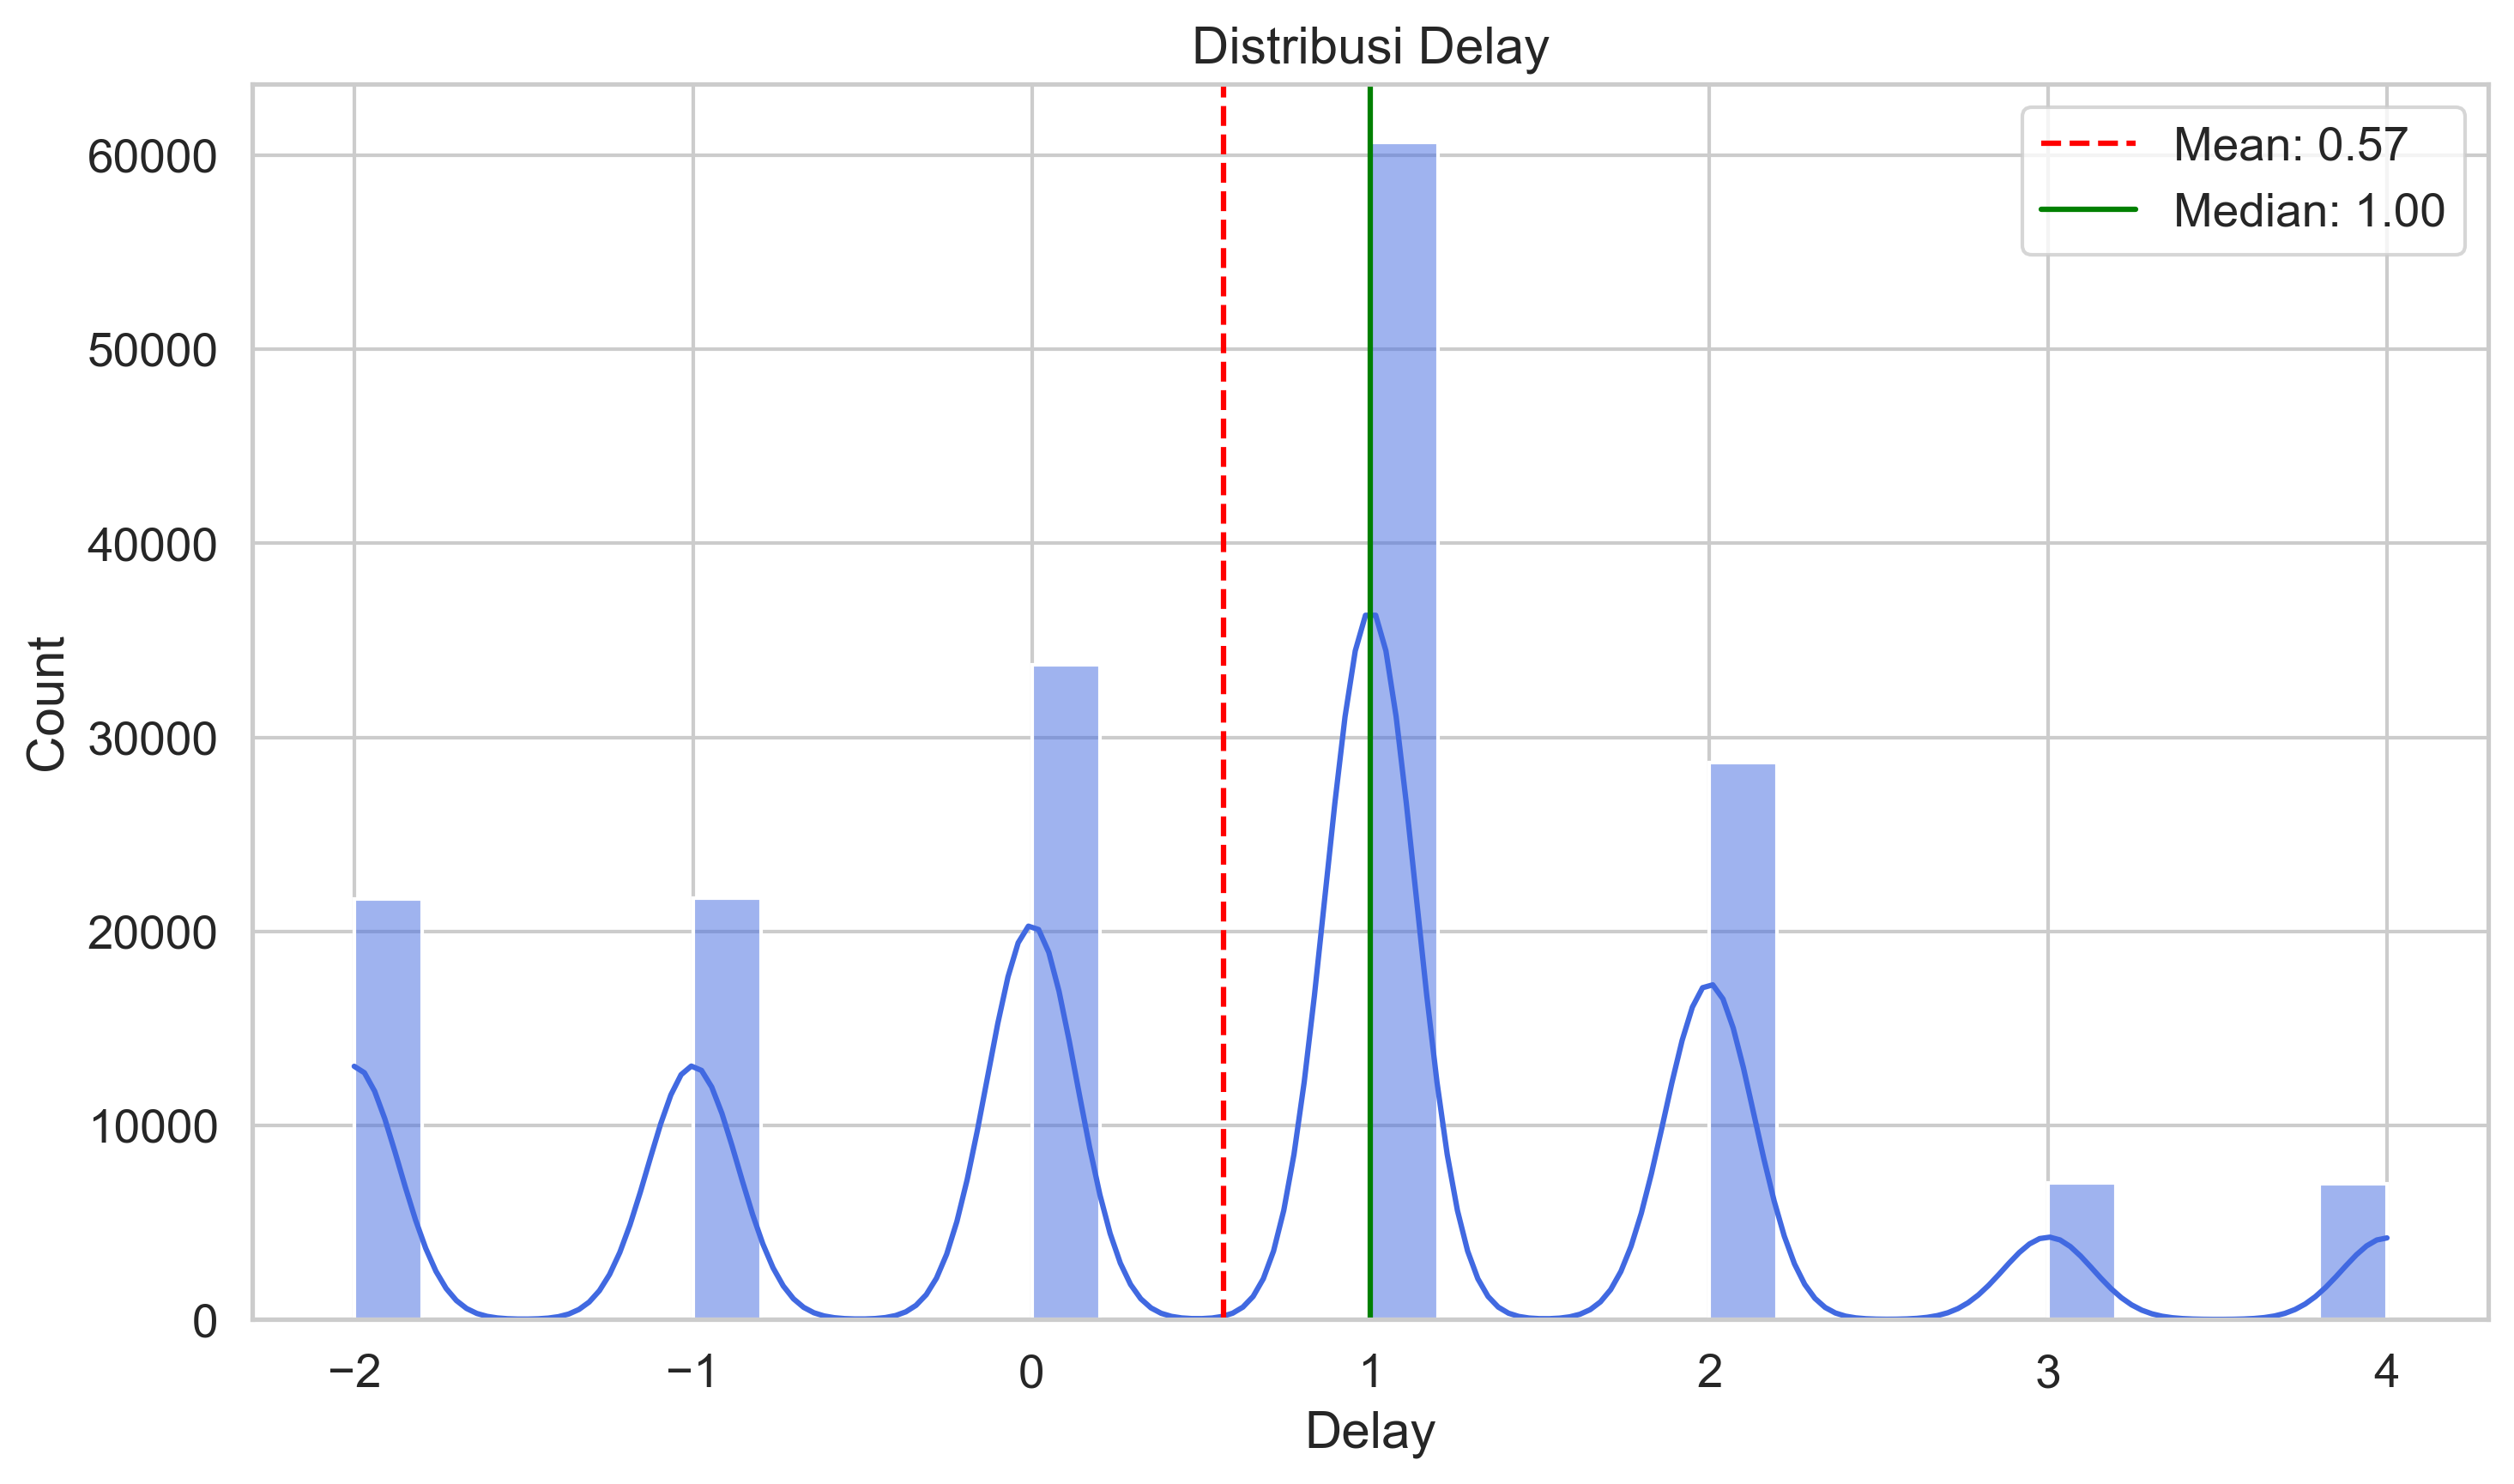

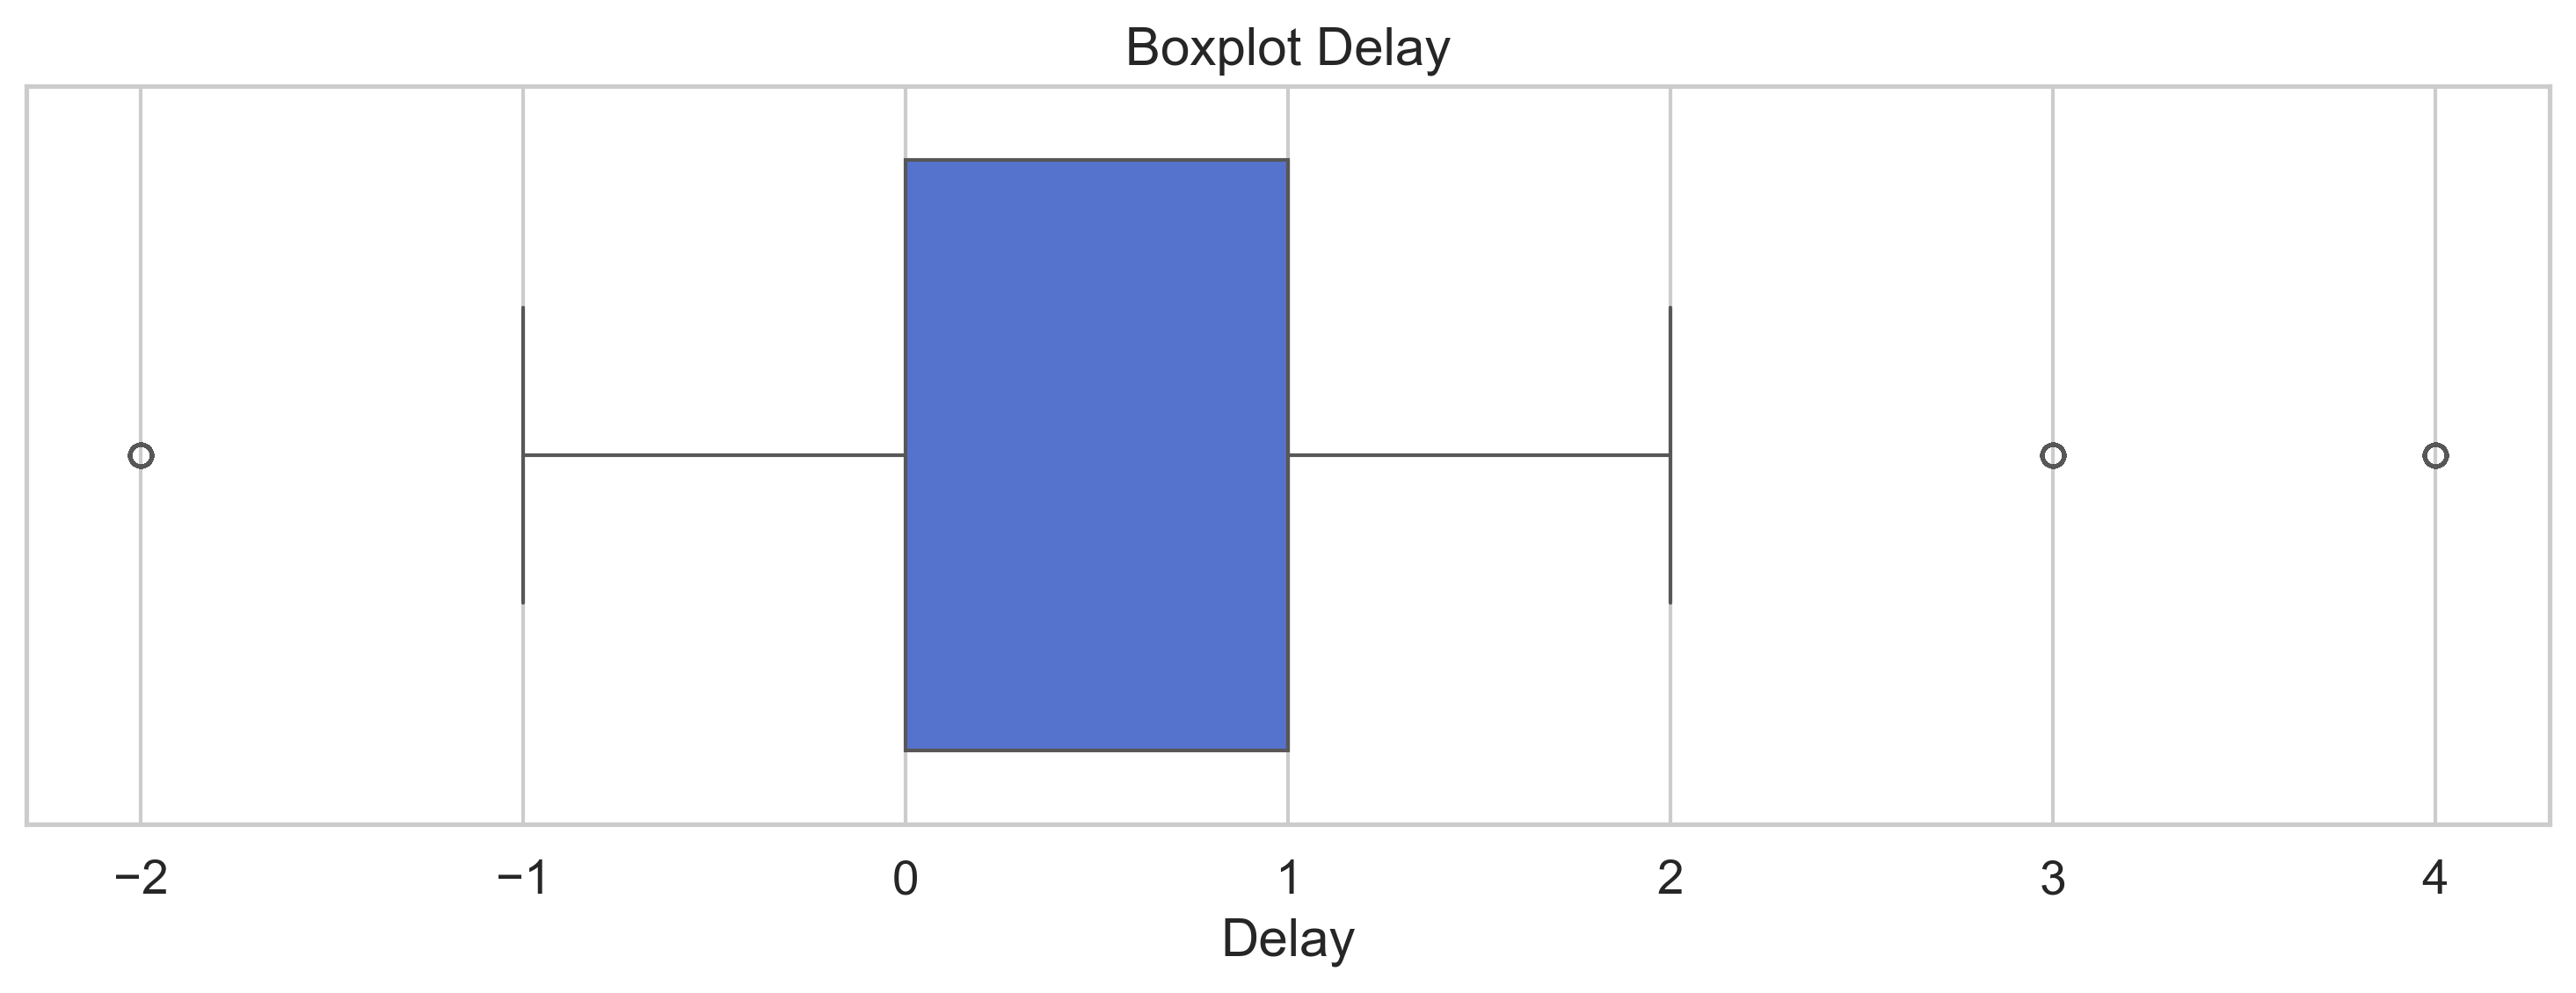

Interpretasi: Mayoritas distribusi data menunjukkan rata-rata keterlambatan sebesar 0.57 hari. Terdapat 57.28% pengiriman yang mengalami keterlambatan yang merupakan fokus dari optimasi ini.


In [4]:
if 'Delay' in df.columns:
    feature = 'Delay'
    mean_val = df[feature].mean()
    median_val = df[feature].median()
    max_val = df[feature].max()
    delayed_pct = (len(df[df[feature] > 0]) / len(df)) * 100
    
    print(f"Mean Delay: {mean_val:.2f}")
    print(f"Max Delay: {max_val:.2f}")
    print(f"Percentage of delayed deliveries: {delayed_pct:.2f}%")
    
    # 1 & 2. Histogram & KDE
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.histplot(df[feature], kde=True, color='royalblue', bins=30, ax=ax)
    ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')
    ax.set_title(f'Distribusi {feature}')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    # 3. Boxplot
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.boxplot(x=df[feature], color='royalblue', ax=ax)
    ax.set_title(f'Boxplot {feature}')
    plt.tight_layout()
    plt.show()
    
    print(f"Interpretasi: Mayoritas distribusi data menunjukkan rata-rata keterlambatan sebesar {mean_val:.2f} hari. Terdapat {delayed_pct:.2f}% pengiriman yang mengalami keterlambatan yang merupakan fokus dari optimasi ini.")

## Analisis Jarak (Distance Analysis)

Average Distance: 2525.20
Maximum Distance: 14501.57
Distance Quartiles (Q1, Q3): 1662.10, 3907.53


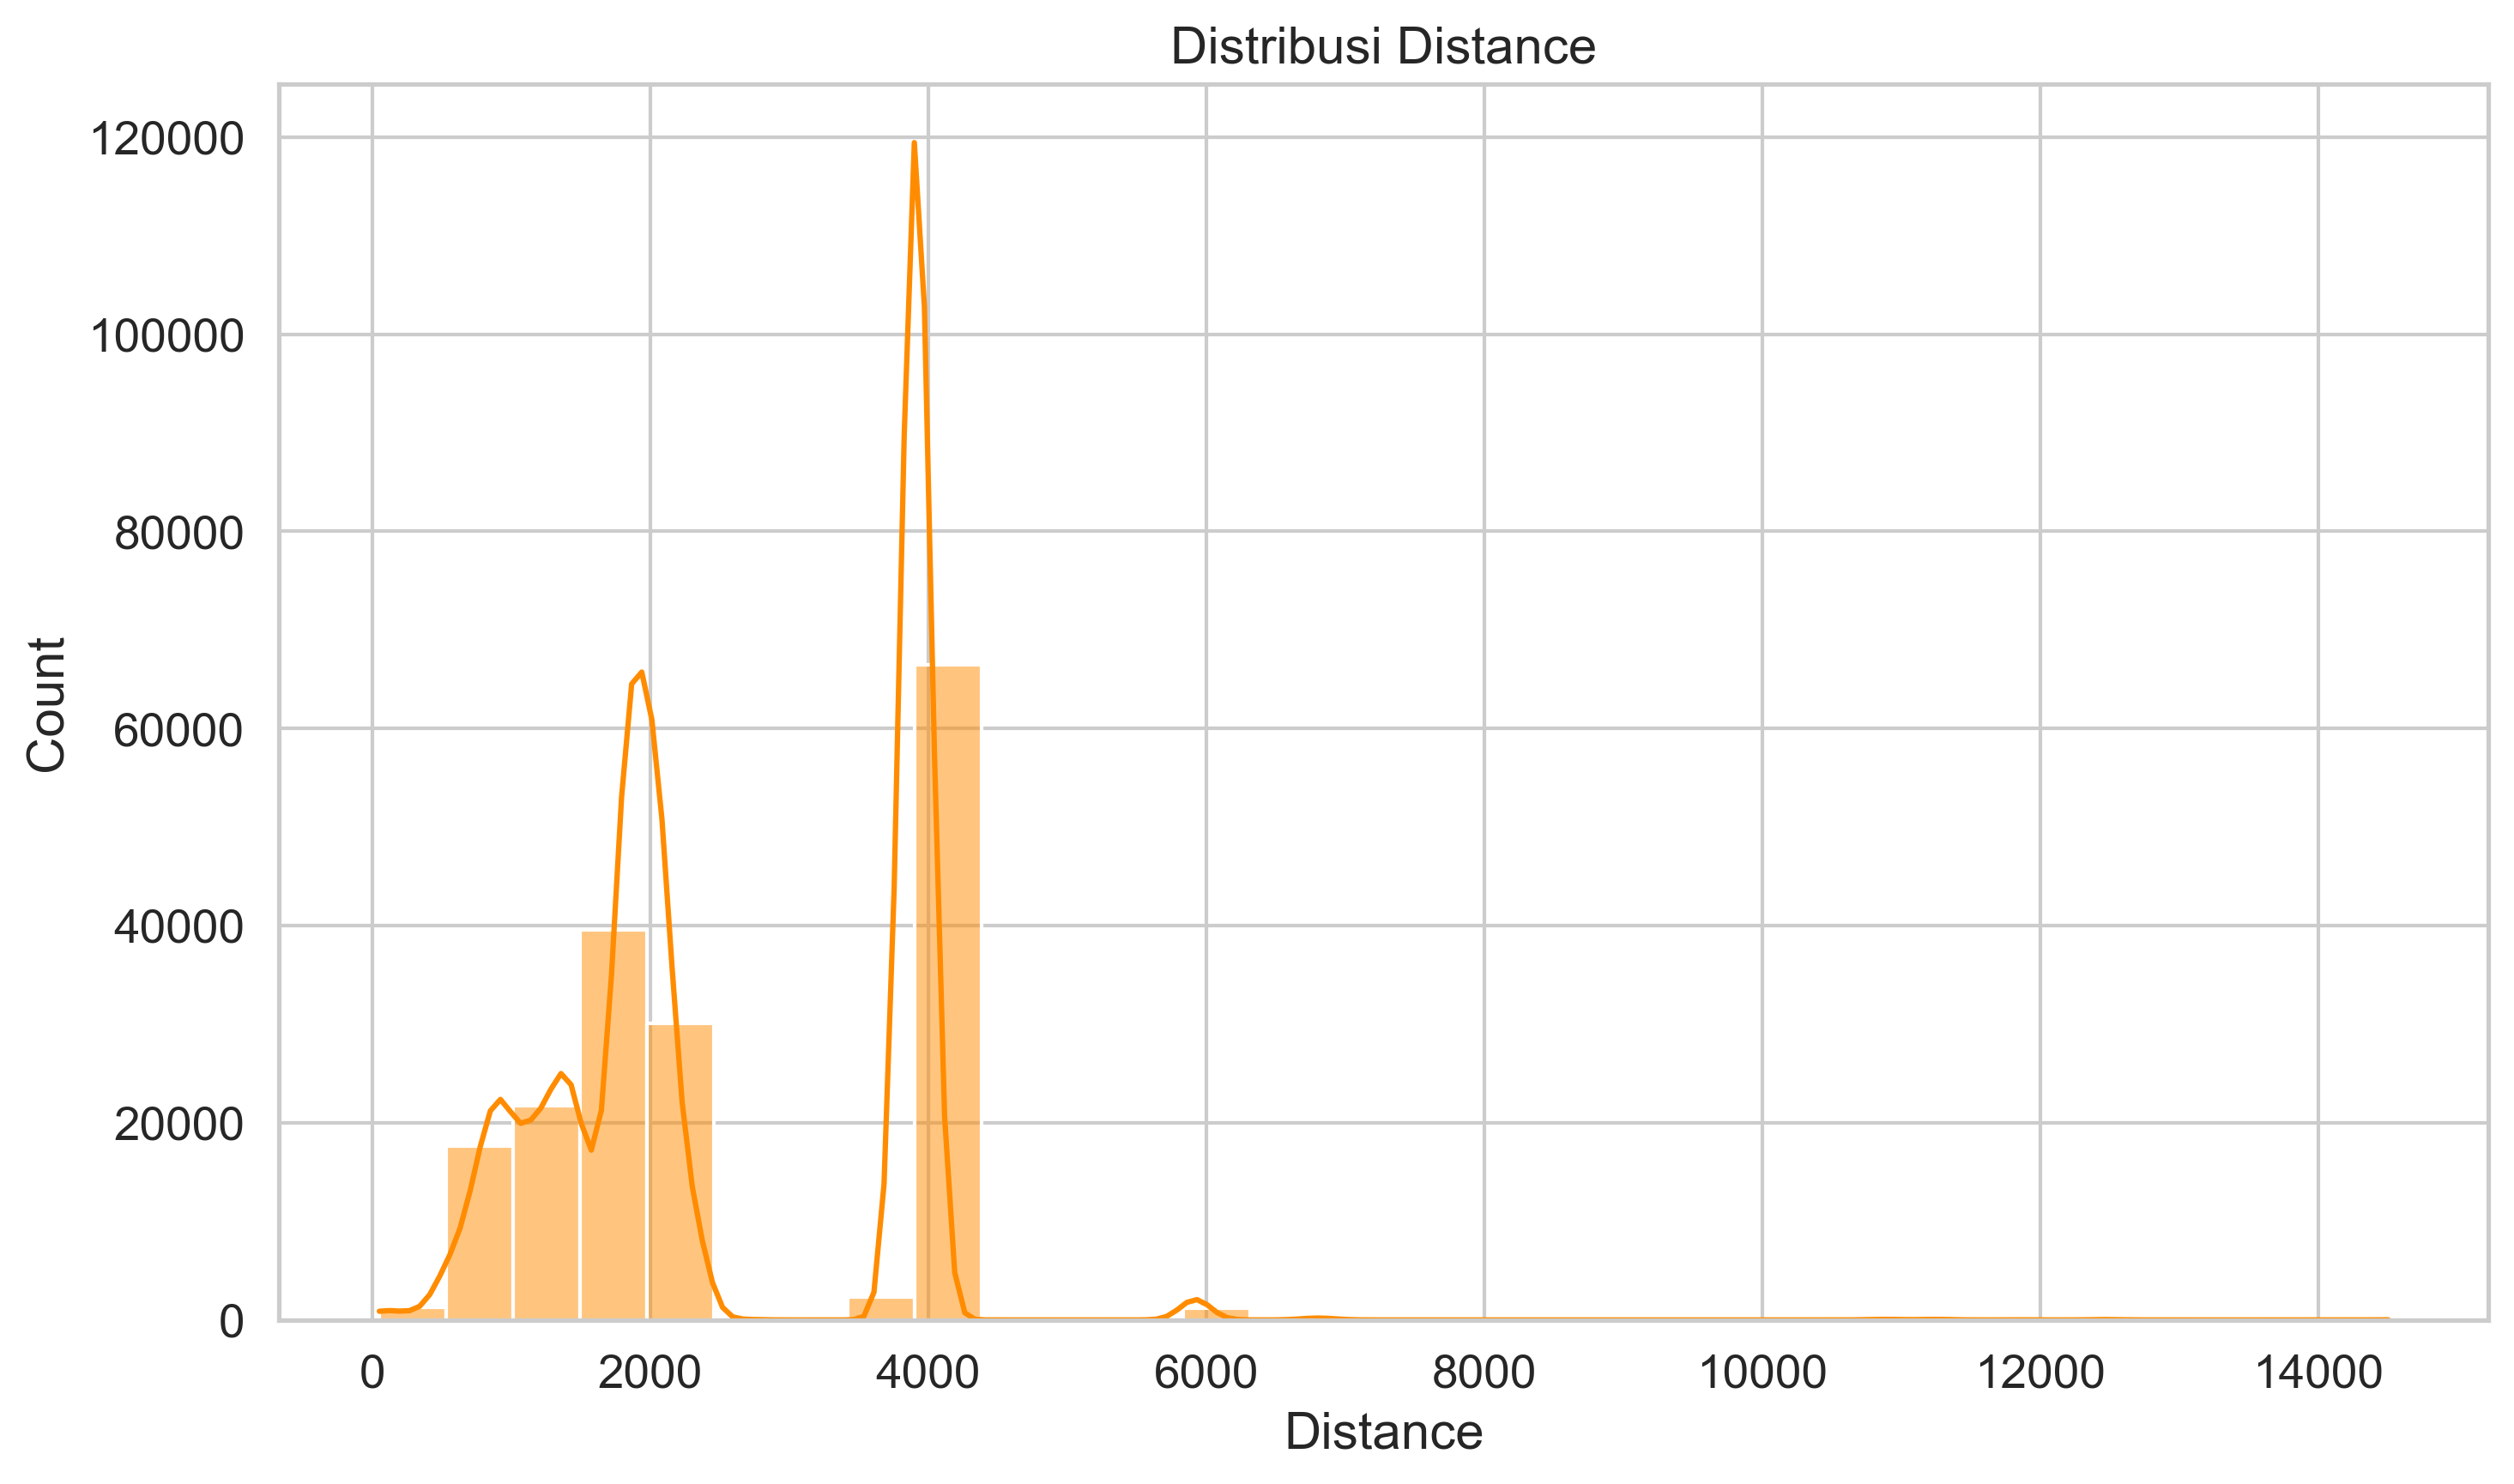

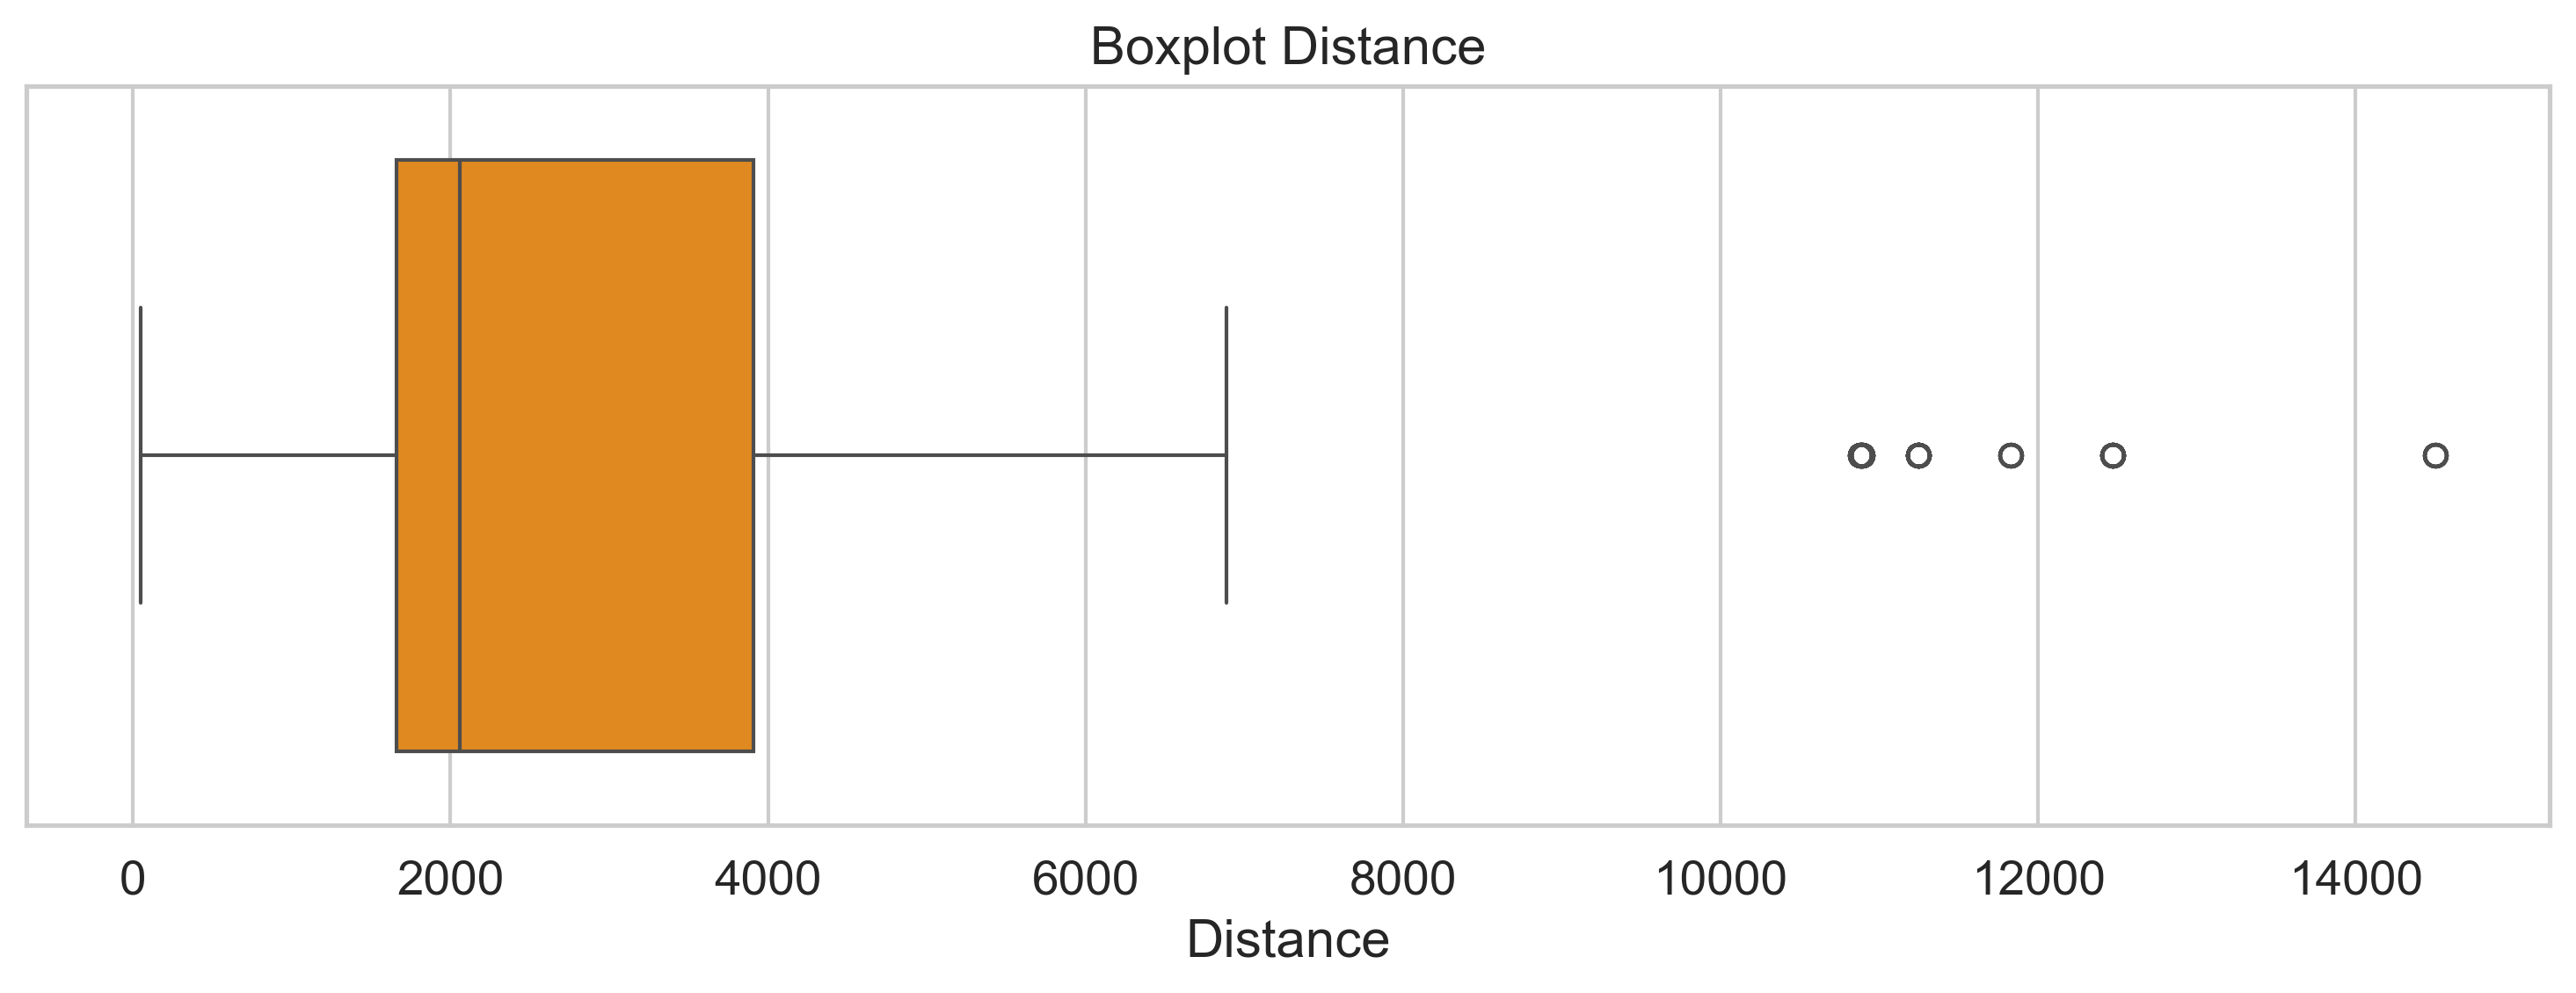

Interpretasi: Jarak memiliki persebaran dengan rata-rata 2525.20. Profil rute ini menunjukkan cakupan logistik jarak jauh hingga maksimal 14501.57.


In [5]:
if 'Distance' in df.columns:
    feature = 'Distance'
    mean_val = df[feature].mean()
    max_val = df[feature].max()
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    
    print(f"Average Distance: {mean_val:.2f}")
    print(f"Maximum Distance: {max_val:.2f}")
    print(f"Distance Quartiles (Q1, Q3): {q1:.2f}, {q3:.2f}")
    
    # Histogram & KDE
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.histplot(df[feature], kde=True, color='darkorange', bins=30, ax=ax)
    ax.set_title(f'Distribusi {feature}')
    plt.tight_layout()
    plt.show()
    
    # Boxplot
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.boxplot(x=df[feature], color='darkorange', ax=ax)
    ax.set_title(f'Boxplot {feature}')
    plt.tight_layout()
    plt.show()
    
    print(f"Interpretasi: Jarak memiliki persebaran dengan rata-rata {mean_val:.2f}. Profil rute ini menunjukkan cakupan logistik jarak jauh hingga maksimal {max_val:.2f}.")

## Analisis Risiko Rute (Route Risk Analysis)

Mean RouteRisk: 0.3085
Maximum RouteRisk: 0.9445


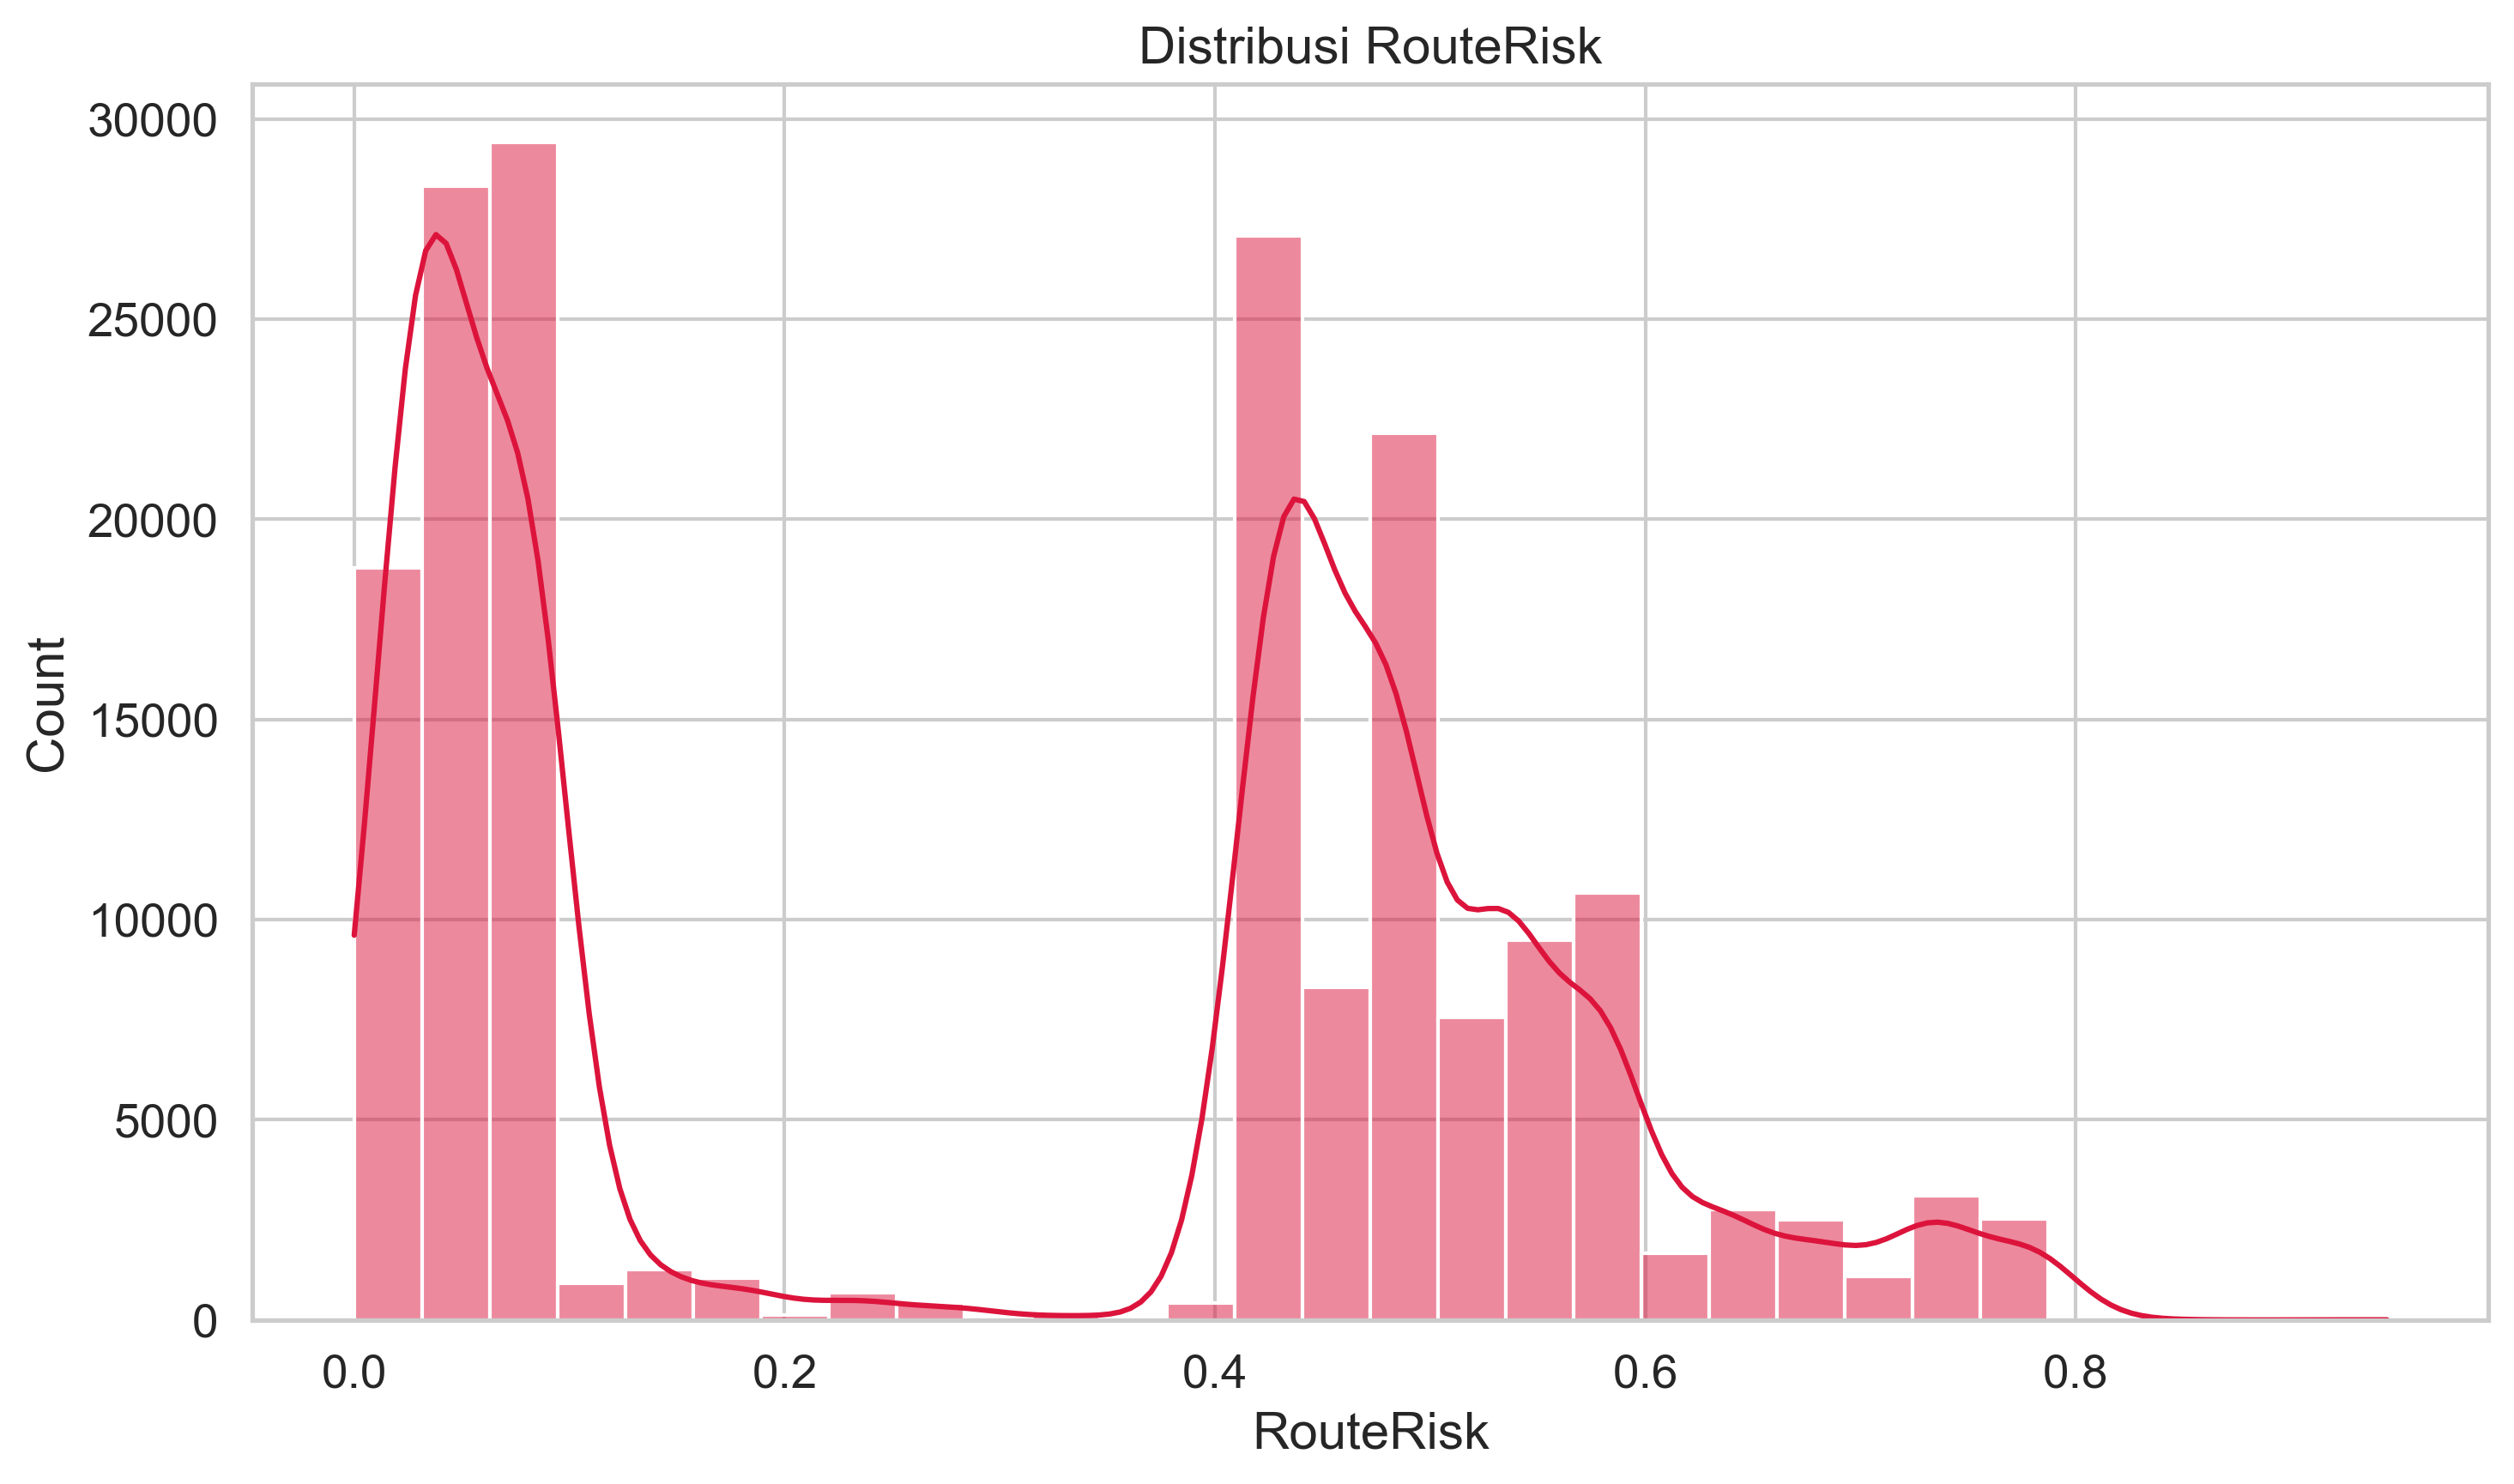

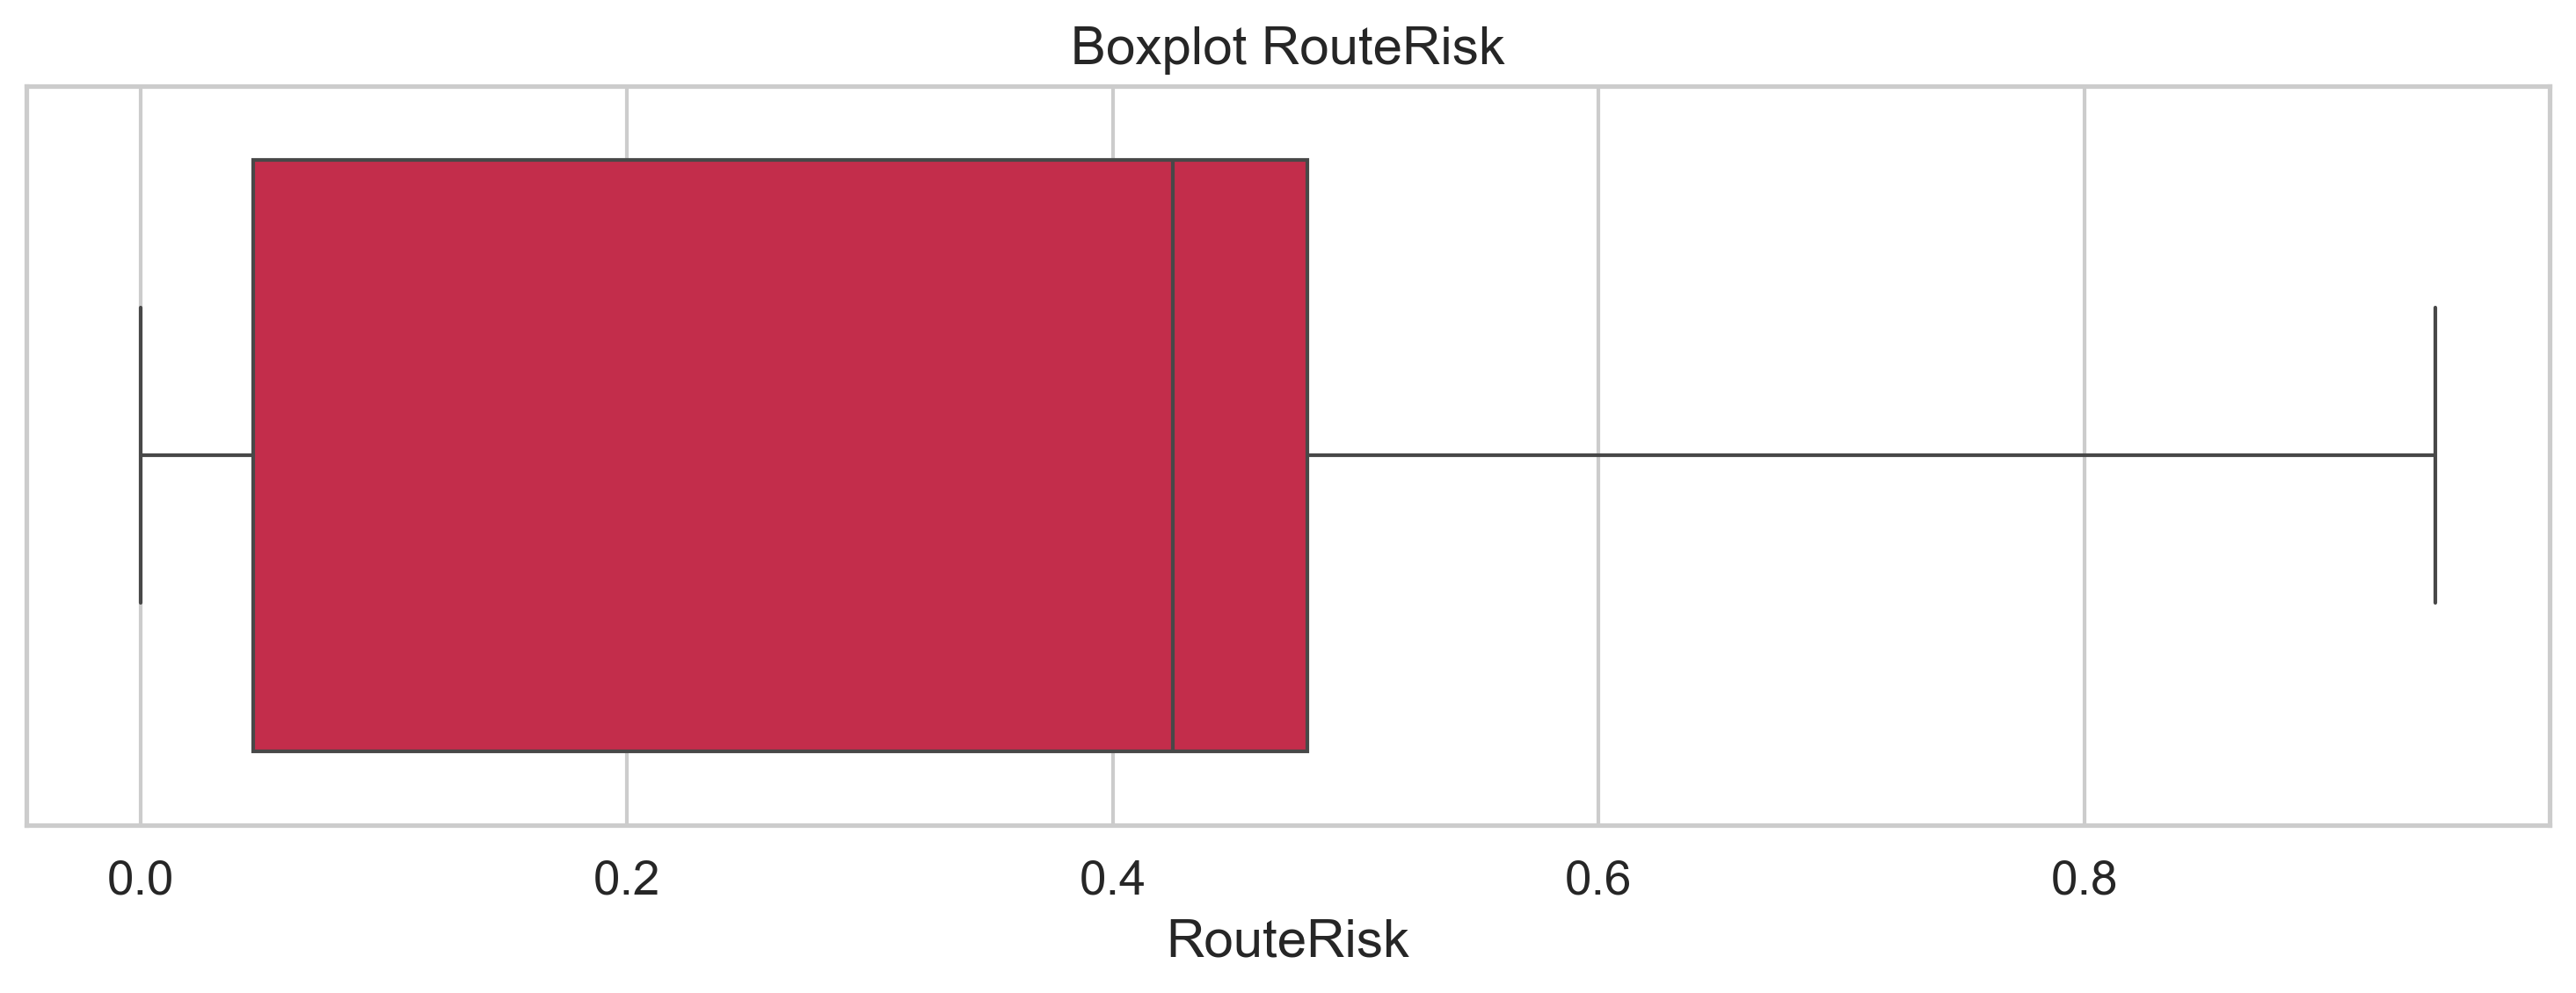

Interpretasi: Risiko komposit memberikan nilai berkesinambungan bagi model optimasi. Rata-rata paparan risiko berada pada angka 0.3085.


In [6]:
if 'RouteRisk' in df.columns:
    feature = 'RouteRisk'
    mean_val = df[feature].mean()
    max_val = df[feature].max()
    
    print(f"Mean RouteRisk: {mean_val:.4f}")
    print(f"Maximum RouteRisk: {max_val:.4f}")
    
    # Histogram & KDE
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.histplot(df[feature], kde=True, color='crimson', bins=30, ax=ax)
    ax.set_title(f'Distribusi {feature}')
    plt.tight_layout()
    plt.show()
    
    # Boxplot
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.boxplot(x=df[feature], color='crimson', ax=ax)
    ax.set_title(f'Boxplot {feature}')
    plt.tight_layout()
    plt.show()
    
    print(f"Interpretasi: Risiko komposit memberikan nilai berkesinambungan bagi model optimasi. Rata-rata paparan risiko berada pada angka {mean_val:.4f}.")

## Analisis Simulasi Rantai Pasok Pendingin

=== TempDev ===
Mean: 0.2086 | Std: 0.1968 | Min: 0.0000 | Max: 0.7850


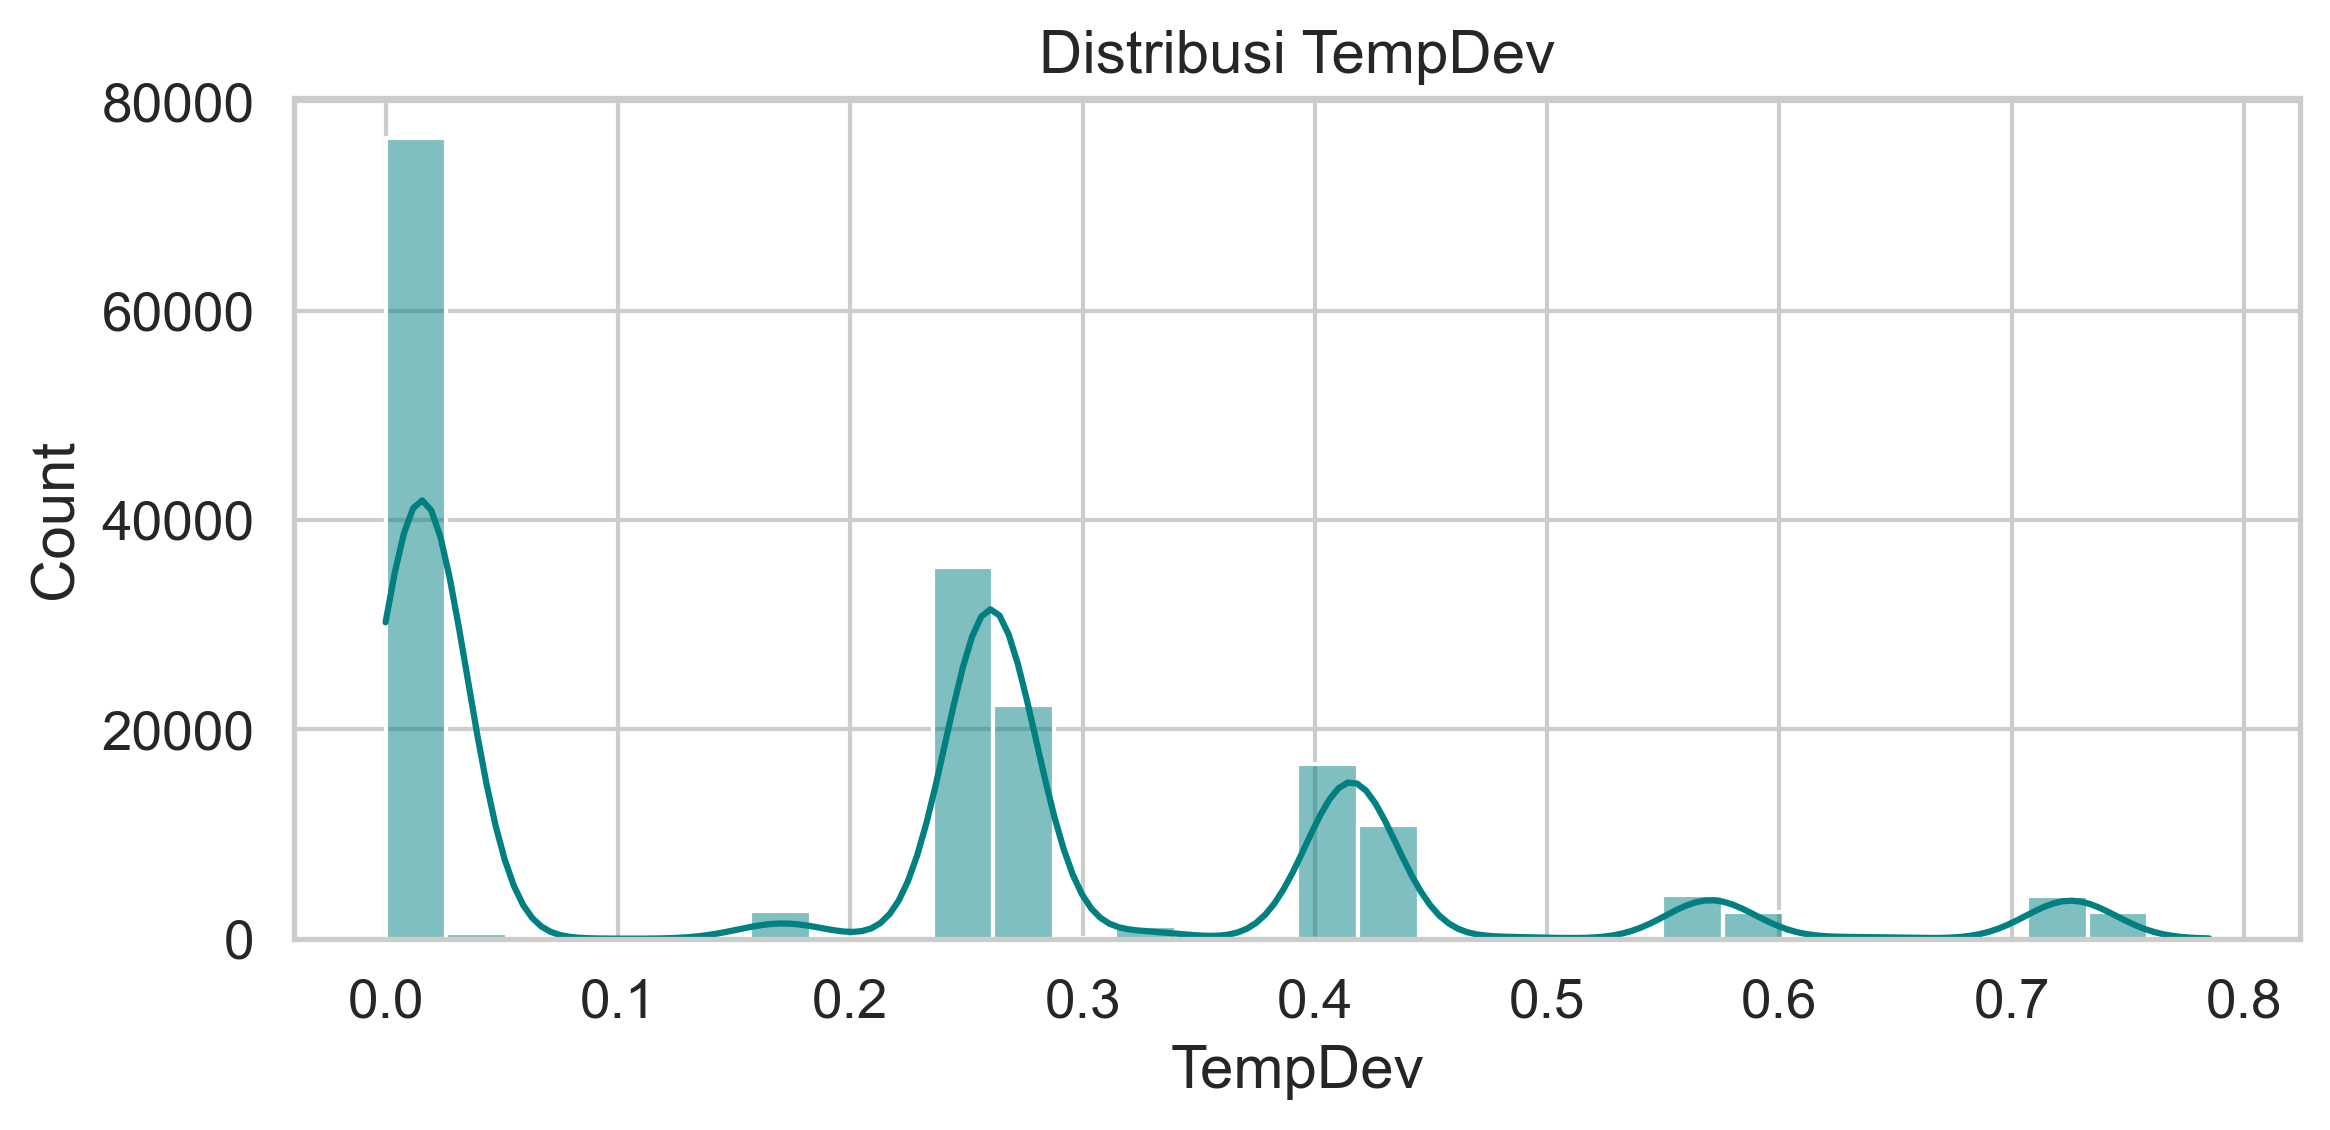

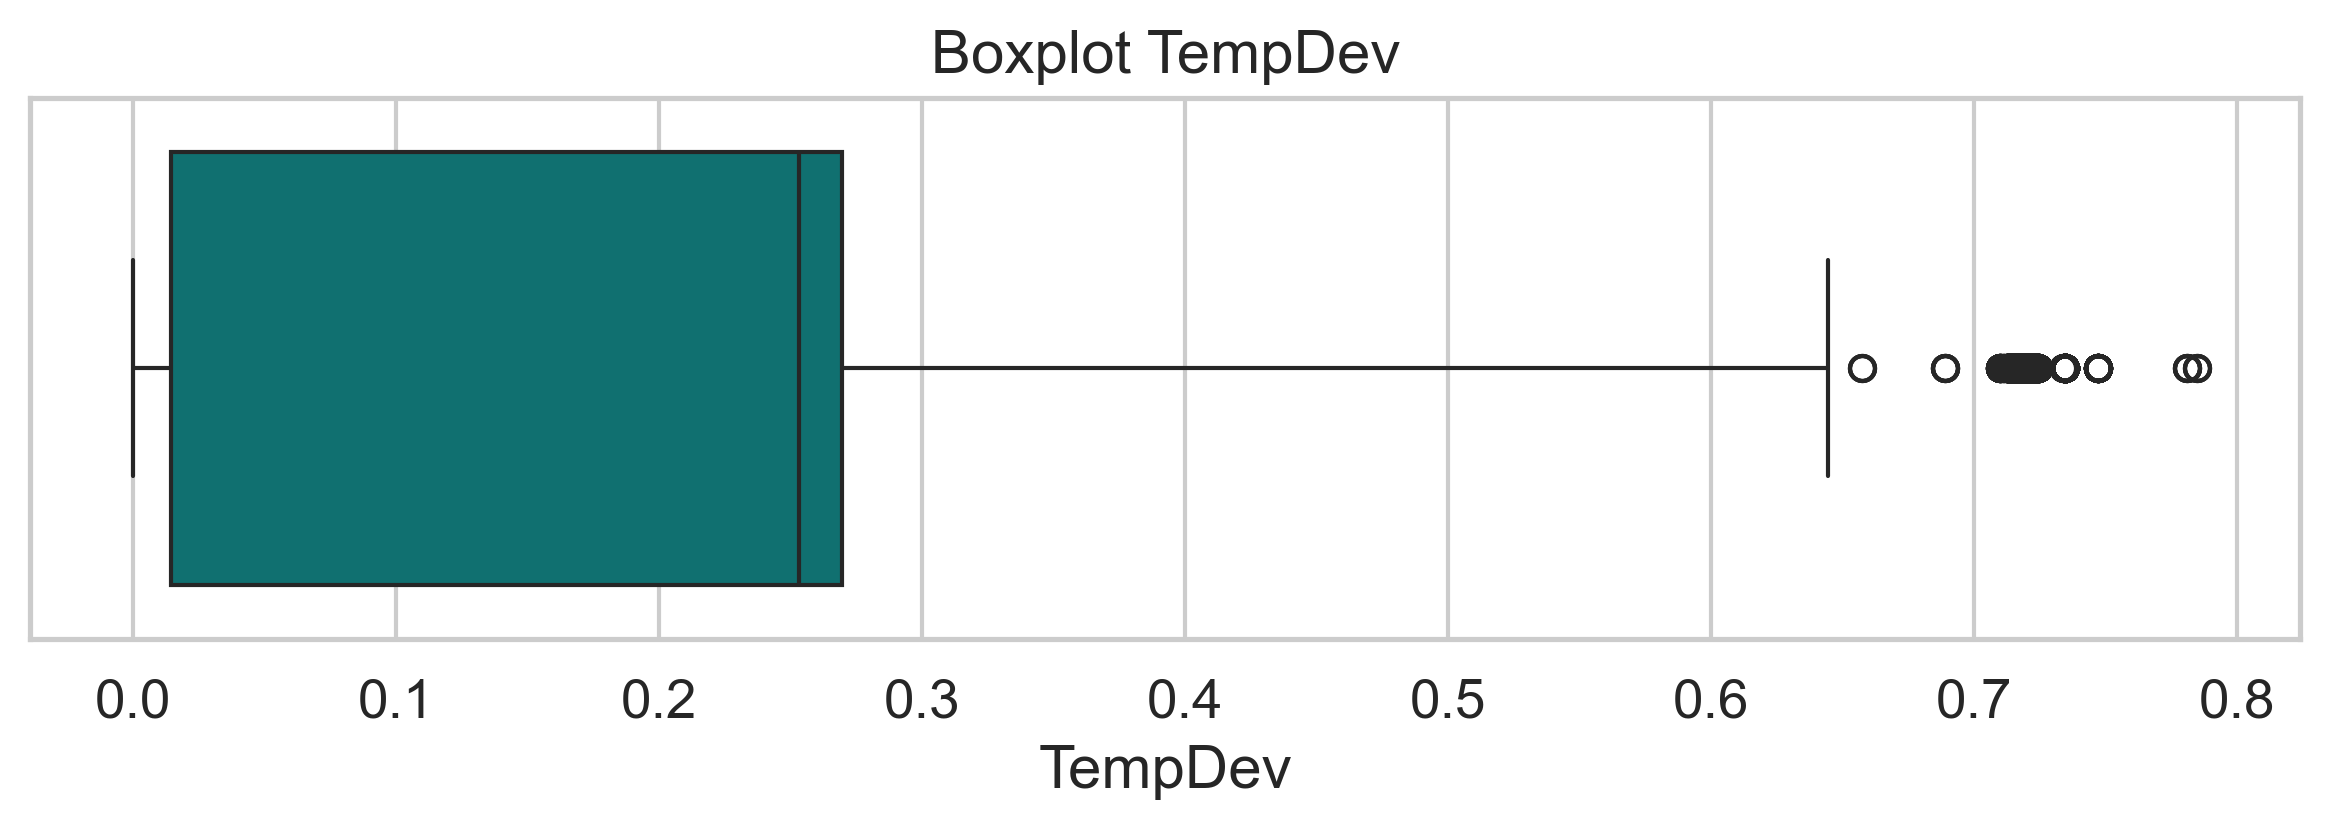

=== QualityDegradation ===
Mean: 97.8485 | Std: 2.2054 | Min: 91.4618 | Max: 100.0000


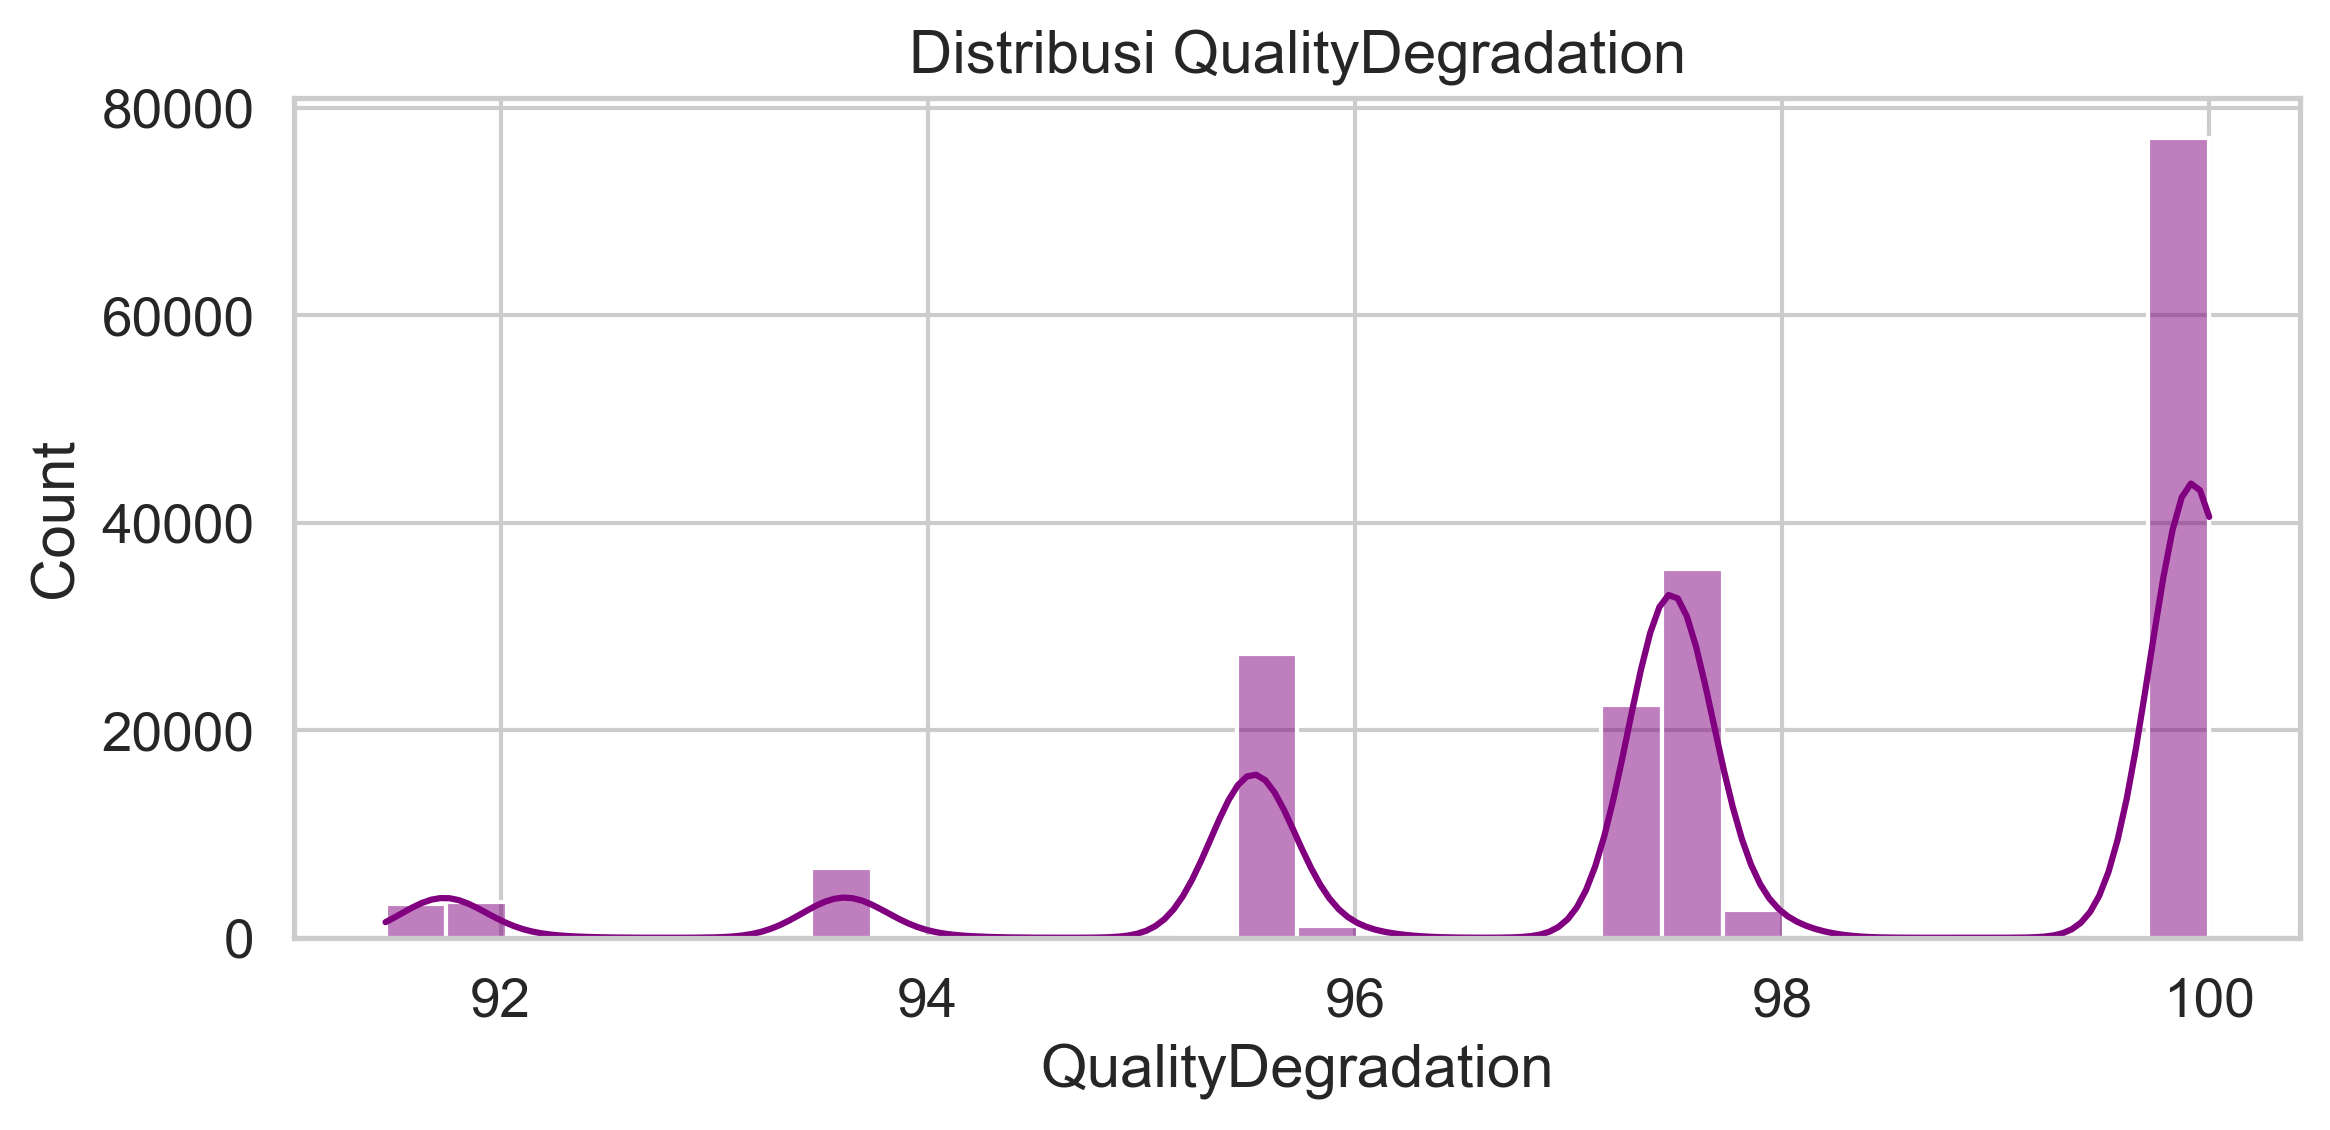

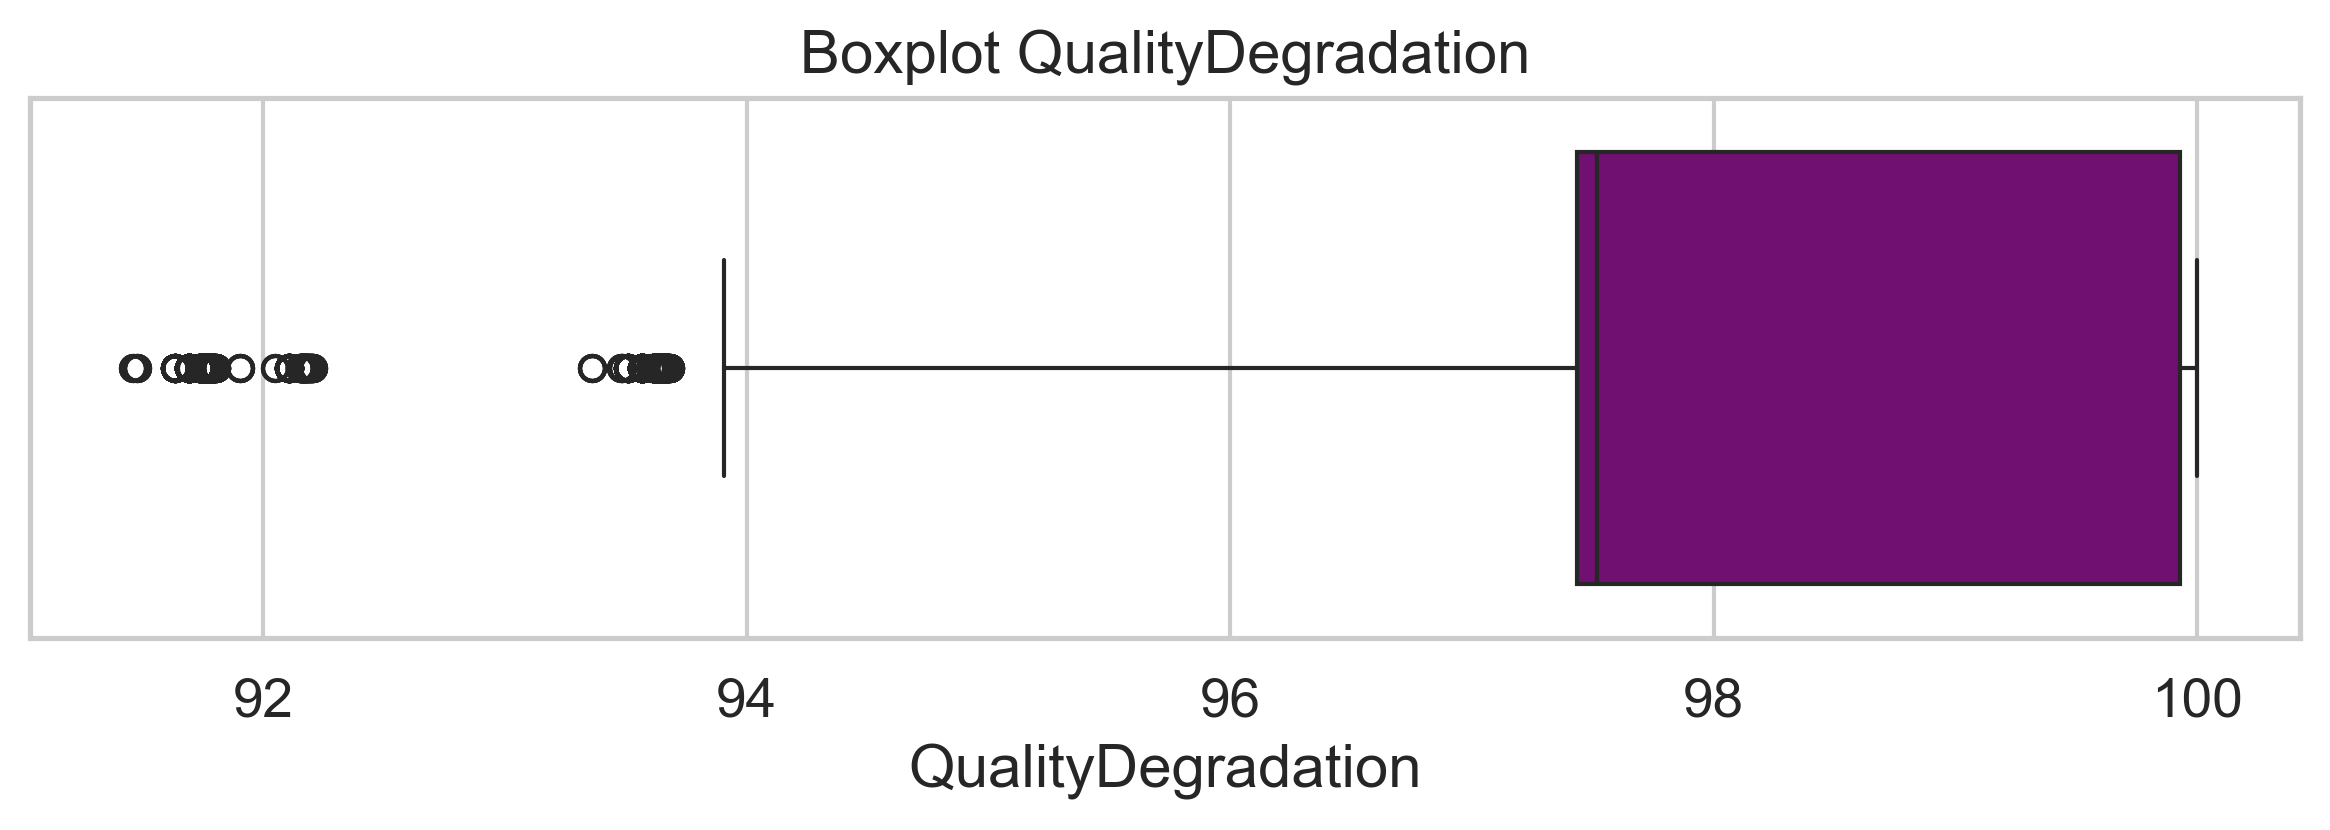

=== RefrigerationCost ===
Mean: 3869.0758 | Std: 2686.8203 | Min: 50.9964 | Max: 31178.2960


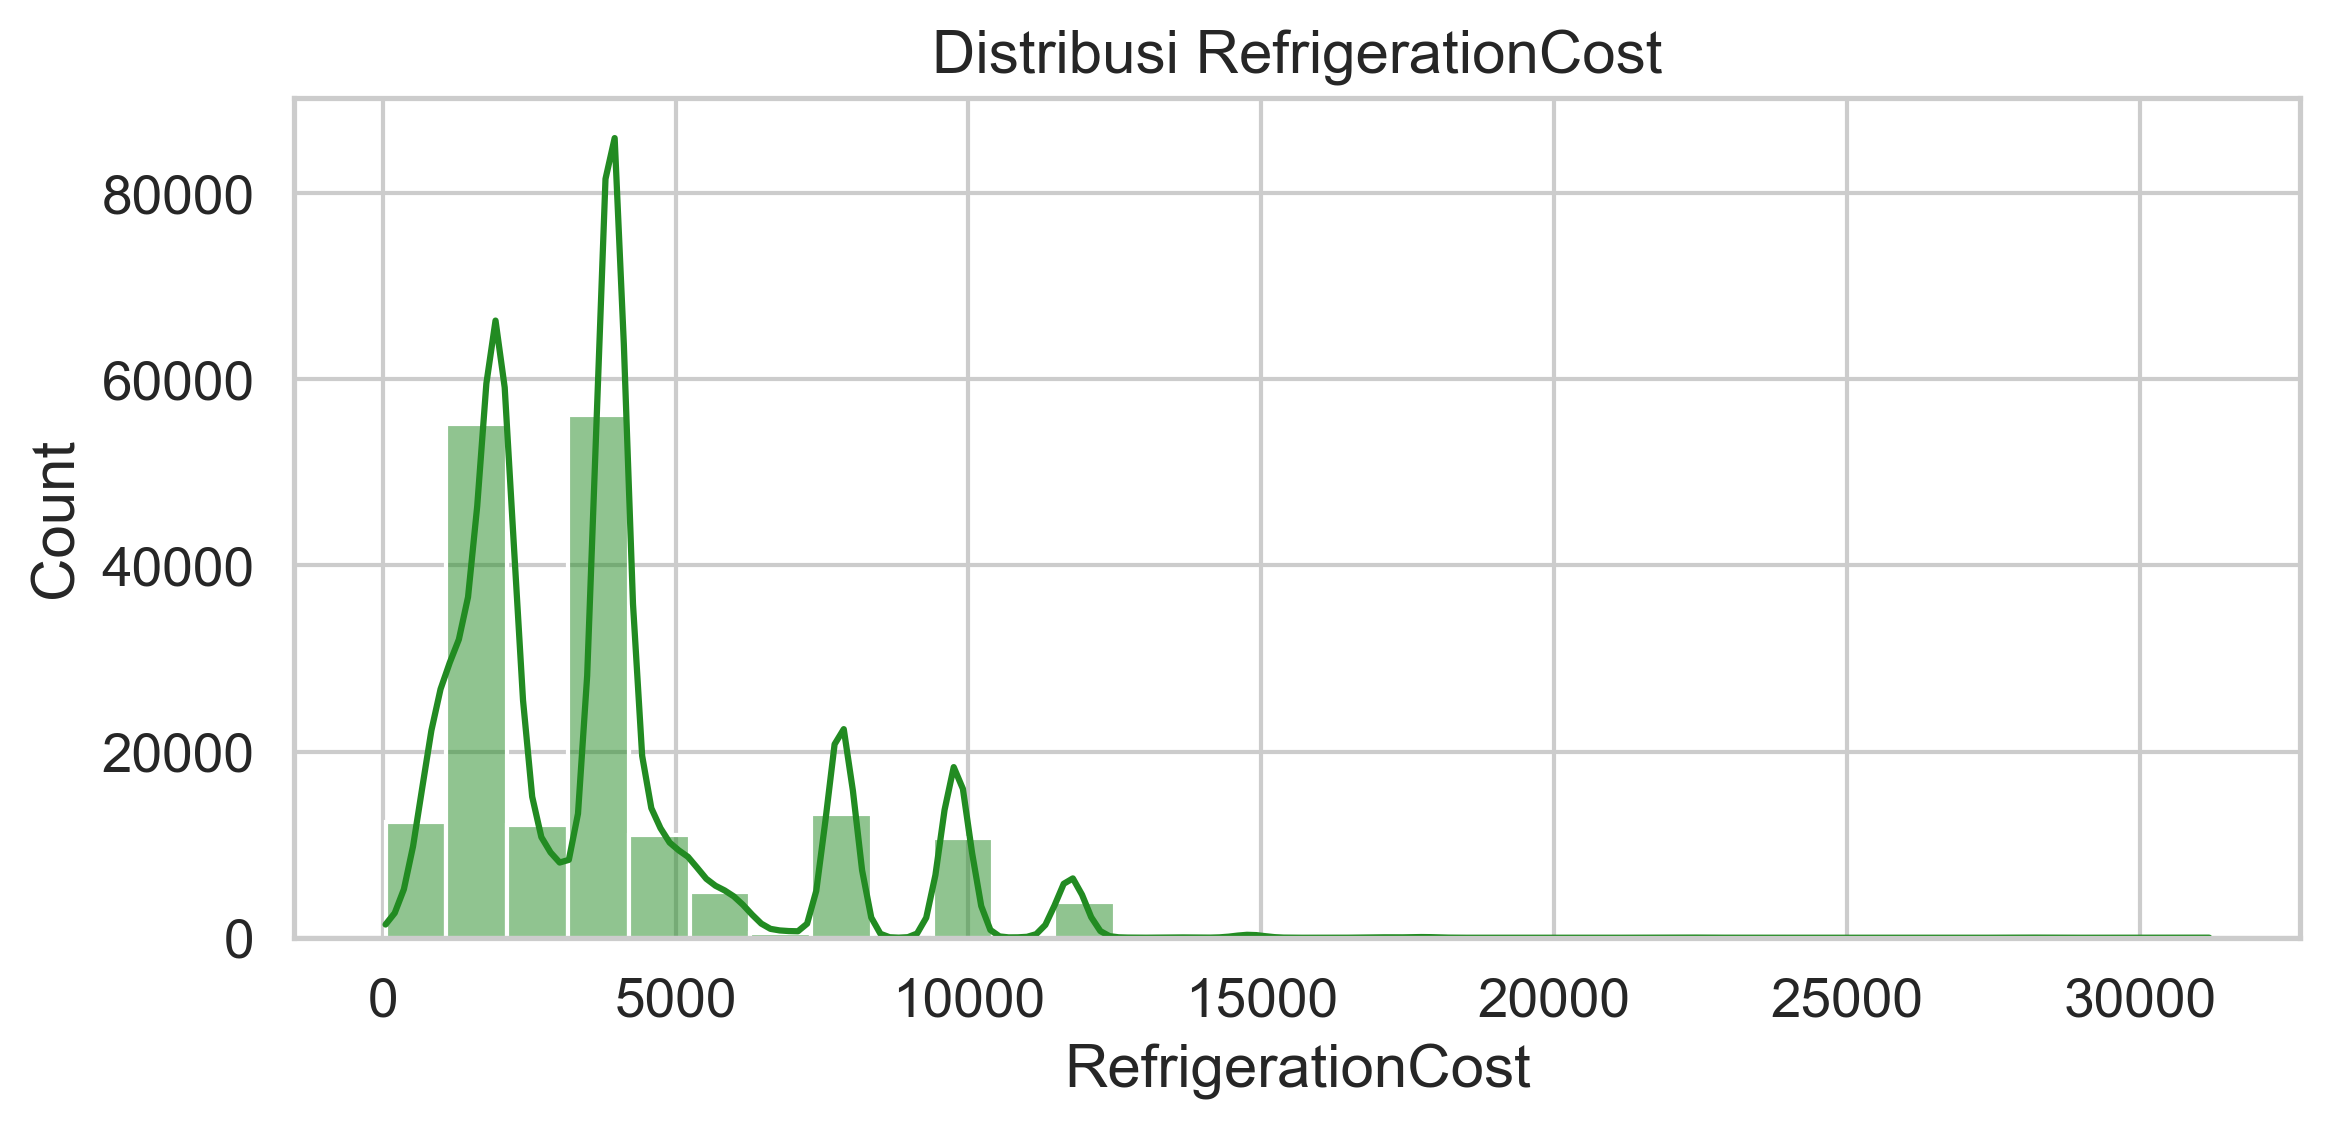

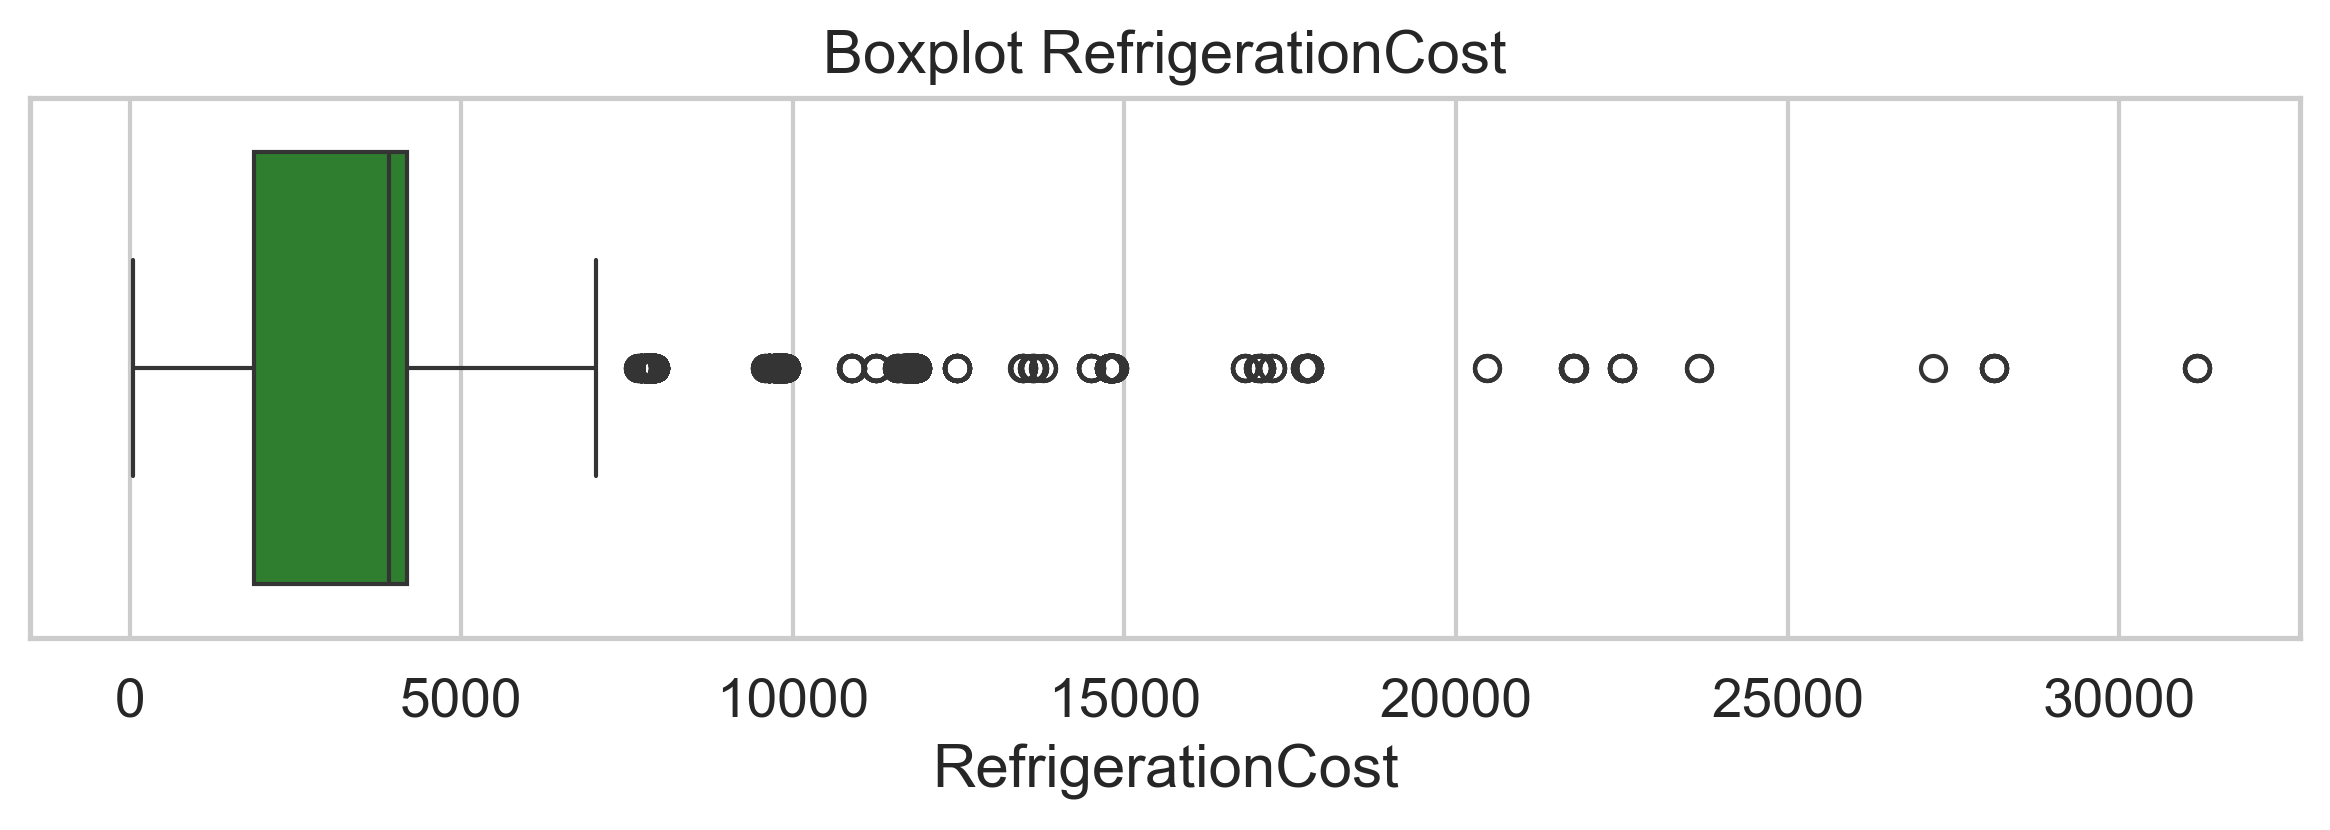

In [7]:
cc_features = ['TempDev', 'QualityDegradation', 'RefrigerationCost']
colors = ['teal', 'purple', 'forestgreen']

for i, feature in enumerate(cc_features):
    if feature in df.columns:
        mean_val = df[feature].mean()
        std_val = df[feature].std()
        min_val = df[feature].min()
        max_val = df[feature].max()
        
        print(f"=== {feature} ===")
        print(f"Mean: {mean_val:.4f} | Std: {std_val:.4f} | Min: {min_val:.4f} | Max: {max_val:.4f}")
        
        # Histogram & KDE
        fig, ax = plt.subplots(figsize=(8, 4))
        sns.histplot(df[feature], kde=True, color=colors[i], bins=30, ax=ax)
        ax.set_title(f'Distribusi {feature}')
        plt.tight_layout()
        plt.show()
        
        # Boxplot
        fig, ax = plt.subplots(figsize=(8, 3))
        sns.boxplot(x=df[feature], color=colors[i], ax=ax)
        ax.set_title(f'Boxplot {feature}')
        plt.tight_layout()
        plt.show()

## Analisis Hubungan Antar Variabel (Relationship Analysis)

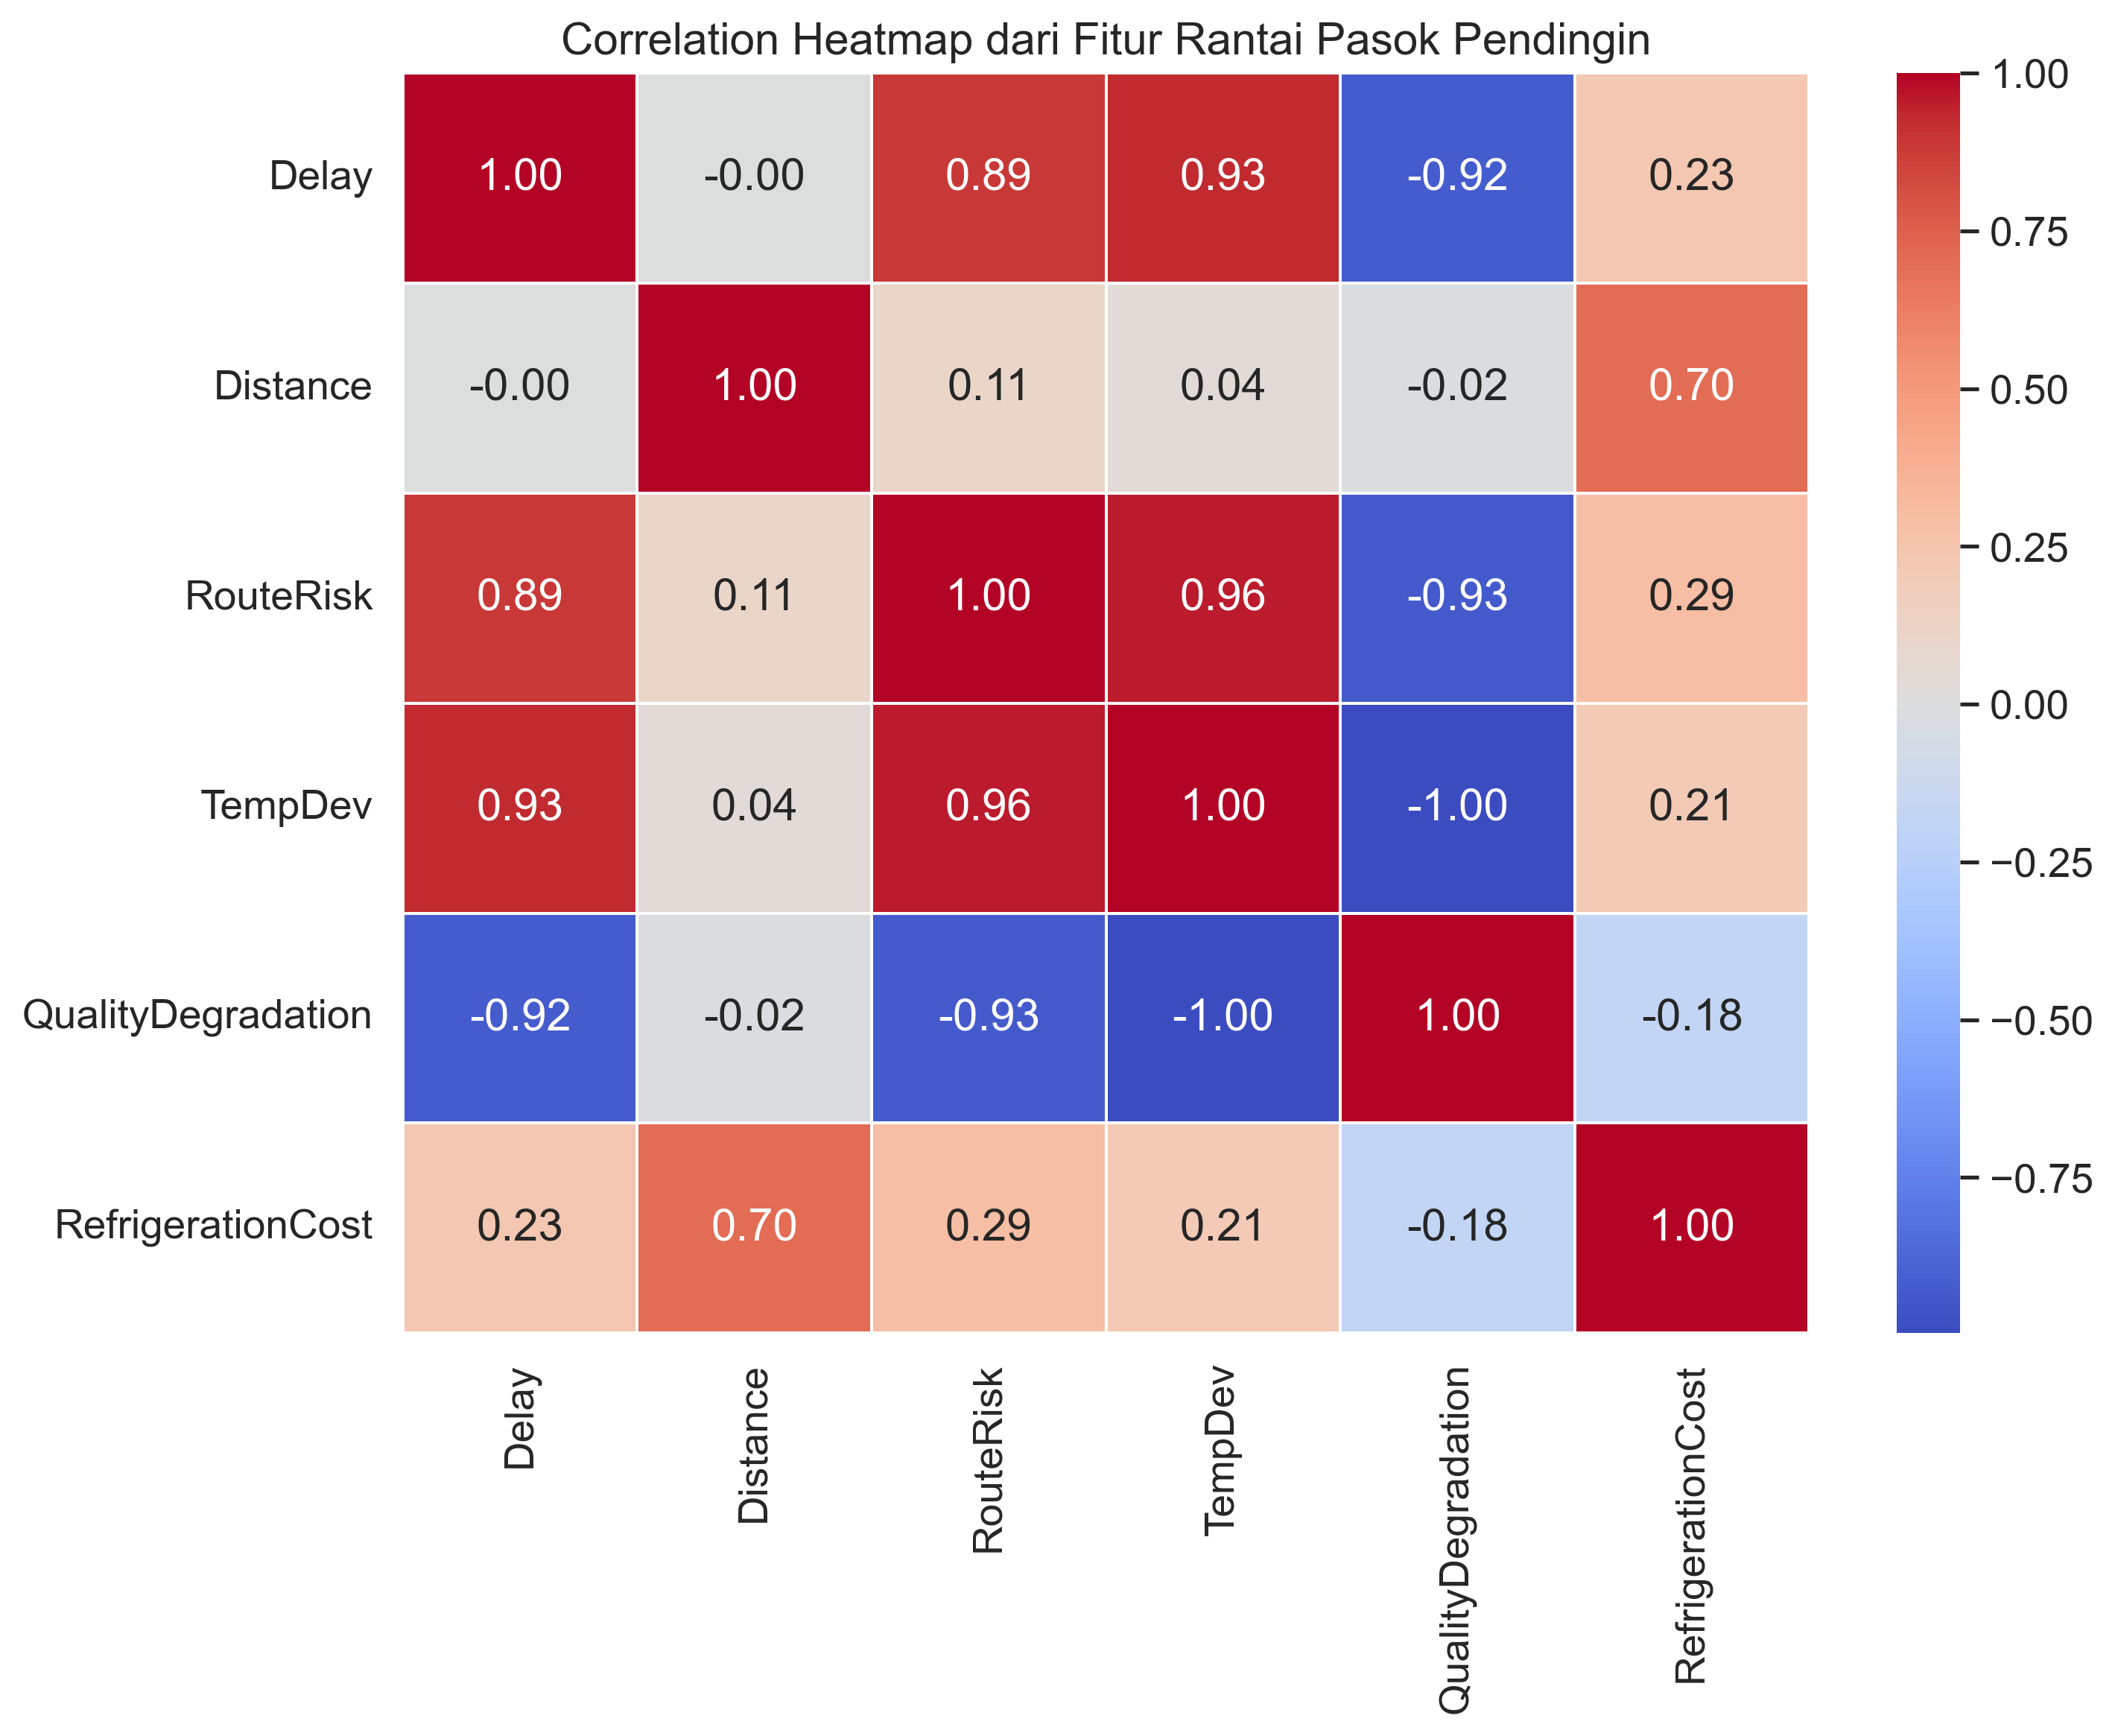

Strongest positive correlation: ('RouteRisk', 'TempDev') (0.9565)
Strongest negative correlation: ('TempDev', 'QualityDegradation') (-0.9967)

Interpretasi: Multikolinearitas dan korelasi antar variabel ini memvalidasi rumusan degradasi kualitas dan risiko. Pengaruh keterlambatan atau jarak terhadap biaya pendinginan terlihat sesuai ekspektasi.


In [8]:
corr_matrix = df[existing_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap dari Fitur Rantai Pasok Pendingin")
plt.tight_layout()
plt.show()

# Find strongest pos and neg correlation (excluding diagonal)
corr_unstacked = corr_matrix.unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 1.0]

strongest_pos = corr_unstacked.idxmax()
strongest_pos_val = corr_unstacked.max()

strongest_neg = corr_unstacked.idxmin()
strongest_neg_val = corr_unstacked.min()

print(f"Strongest positive correlation: {strongest_pos} ({strongest_pos_val:.4f})")
print(f"Strongest negative correlation: {strongest_neg} ({strongest_neg_val:.4f})")
print("\nInterpretasi: Multikolinearitas dan korelasi antar variabel ini memvalidasi rumusan degradasi kualitas dan risiko. Pengaruh keterlambatan atau jarak terhadap biaya pendinginan terlihat sesuai ekspektasi.")

## Dasbor Distribusi Fitur (Feature Distribution Dashboard)

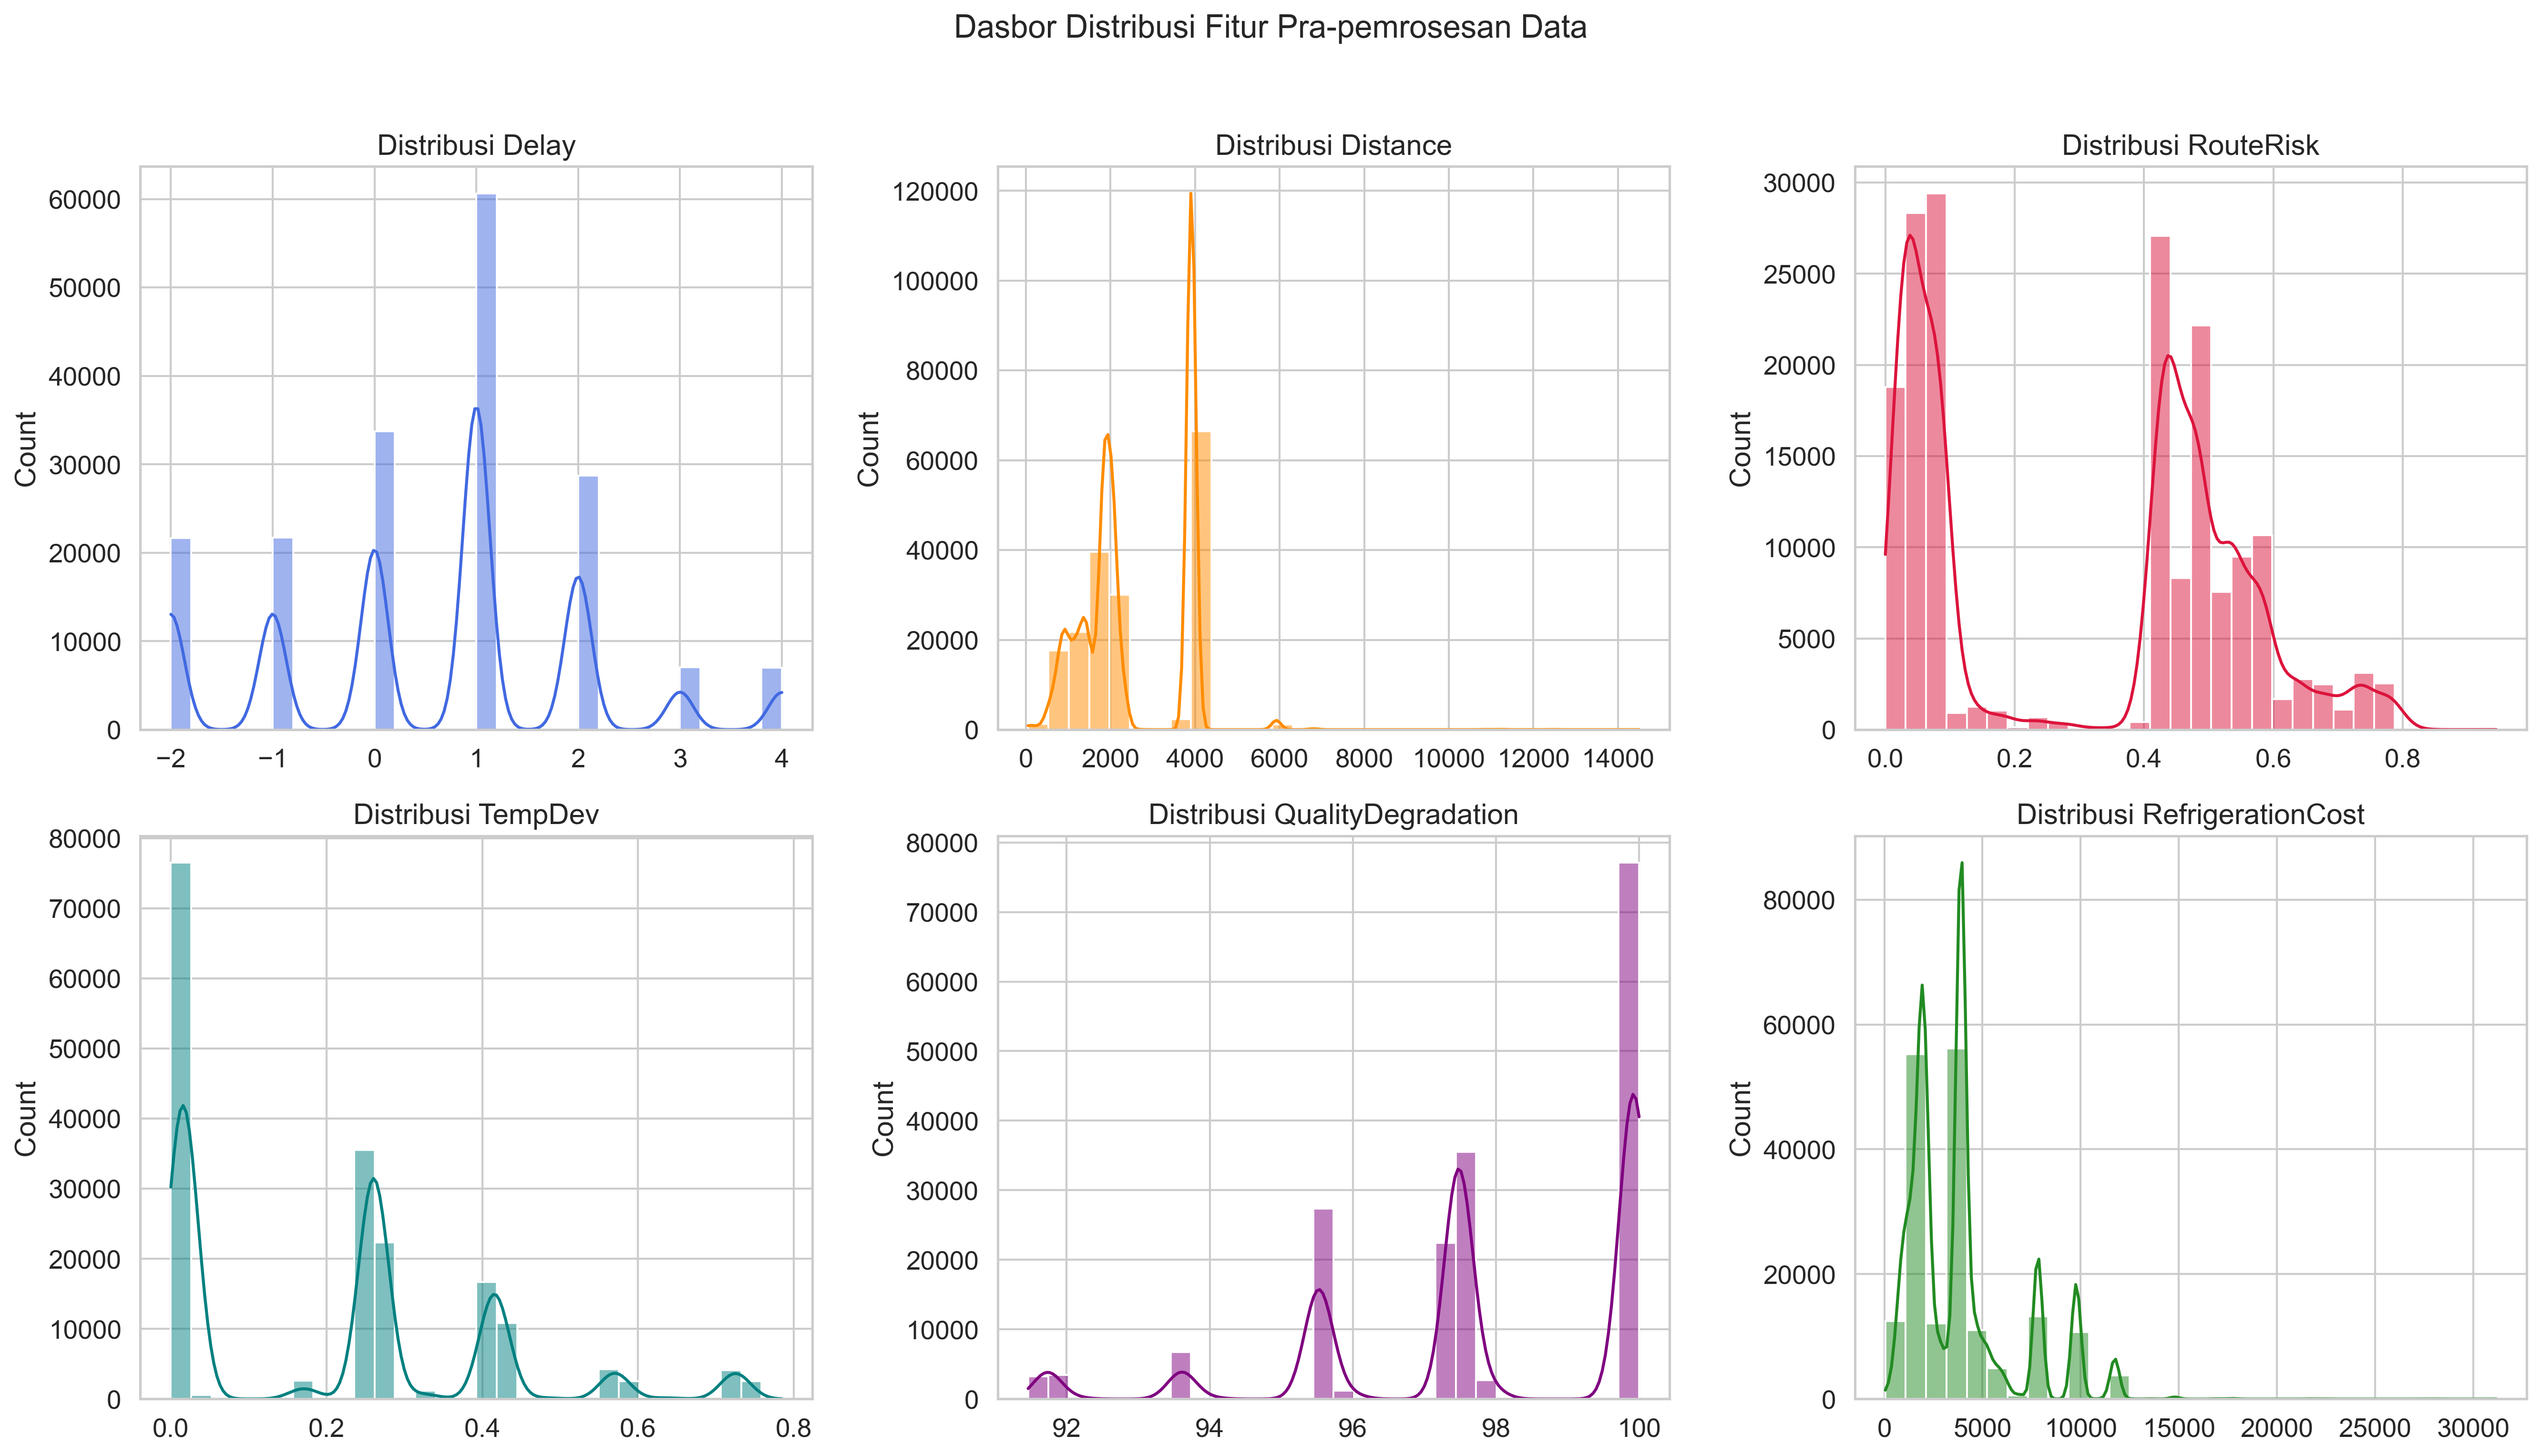

Dasbor gabungan beresolusi tinggi berhasil disimpan sebagai 'feature_dashboard.png'.


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

feature_colors = ['royalblue', 'darkorange', 'crimson', 'teal', 'purple', 'forestgreen']

for i, feature in enumerate(existing_features):
    if i < 6:
        sns.histplot(df[feature], kde=True, ax=axes[i], color=feature_colors[i], bins=30)
        axes[i].set_title(f'Distribusi {feature}')
        axes[i].set_xlabel('')
        
plt.suptitle('Dasbor Distribusi Fitur Pra-pemrosesan Data', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
print("Dasbor gabungan beresolusi tinggi berhasil disimpan sebagai 'feature_dashboard.png'.")

## Tabel Laporan (Report Tables)

Mengekspor subset tabel statistik yang siap disalin ke dalam tesis (format CSV).

In [10]:
# Filter the stats_data generated in Section 2
def export_table(feature_list, filename):
    data = [row for row in stats_data if row['Feature'] in feature_list]
    if data:
        pd.DataFrame(data).to_csv(f'reports/preprocessing/tables/{filename}.csv', index=False)

# Table A: Delay Statistics
export_table(['Delay'], 'table_A_delay_statistics')

# Table B: Distance Statistics
export_table(['Distance'], 'table_B_distance_statistics')

# Table C: RouteRisk Statistics
export_table(['RouteRisk'], 'table_C_routerisk_statistics')

# Table D: Cold Chain Statistics
export_table(['TempDev', 'QualityDegradation', 'RefrigerationCost'], 'table_D_coldchain_statistics')

print("Seluruh tabel laporan tesis (Tabel A, B, C, D) berhasil diekspor.")

Seluruh tabel laporan tesis (Tabel A, B, C, D) berhasil diekspor.


## Dukungan Bab 4 (Chapter 4 Support)

Menghasilkan laporan format Markdown otomatis yang menggabungkan temuan statistik dengan narasinya.

In [11]:
md_content = f"""# Laporan Ringkasan Pra-pemrosesan Data (Bab 4.1)

## 4.1.1 Analisis Keterlambatan (Delay Analysis)
- **Mean (Rata-rata):** {df['Delay'].mean():.2f} hari
- **Max (Maksimal):** {df['Delay'].max():.2f} hari
- **Interpretasi Distribusi:** Mayoritas pengiriman memiliki keterlambatan pada tingkat rata-rata {df['Delay'].mean():.2f}. Mengingat {delayed_pct:.2f}% pengiriman terindikasi terlambat, optimasi AO sangat relevan untuk dieksekusi.

## 4.1.2 Analisis Jarak (Distance Analysis)
- **Mean (Rata-rata):** {df['Distance'].mean():.2f} unit
- **Max (Maksimal):** {df['Distance'].max():.2f} unit
- **Interpretasi Distribusi:** Variansi jarak sangat tinggi, menyebar hingga Q3 sebesar {df['Distance'].quantile(0.75):.2f}. Profil ini meningkatkan ancaman pada kestabilan cold chain selama transit.

## 4.1.3 Analisis Risiko Rute (Route Risk Analysis)
- **Mean (Rata-rata):** {df['RouteRisk'].mean():.4f}
- **Karakteristik Risiko:** Menggabungkan keparahan jarak dan waktu, dengan maksimal observasi mencapai {df['RouteRisk'].max():.4f}.

## 4.1.4 Analisis Simulasi Rantai Pasok Pendingin
### A. Deviasi Suhu (Temperature Deviation)
- **Temuan Statistik:** Rata-rata {df['TempDev'].mean():.4f}, Max {df['TempDev'].max():.4f}
- **Interpretasi:** Deviasi mencerminkan ketidakstabilan pendinginan di luar batas kendali.
- **Implikasi bagi Logistik Cold Chain:** Sangat kritis terhadap umur simpan, setiap peningkatan skor ini mempercepat kebusukan.

### B. Degradasi Kualitas (Quality Degradation)
- **Temuan Statistik:** Rata-rata {df['QualityDegradation'].mean():.4f}, Min {df['QualityDegradation'].min():.4f}
- **Interpretasi:** Pola degradasi terlihat meluruh secara eksponensial seperti asumsi rumus awal.
- **Implikasi bagi Logistik Cold Chain:** Memaksa algoritma optimasi untuk mencari *trade-off* (kompromi) agar barang tiba dengan ambang mutu yang wajar.

### C. Biaya Pendinginan (Refrigeration Cost)
- **Temuan Statistik:** Rata-rata {df['RefrigerationCost'].mean():.4f}, Max {df['RefrigerationCost'].max():.4f}
- **Interpretasi:** Berkorelasi sangat erat dengan durasi dan mode pengiriman.
- **Implikasi bagi Logistik Cold Chain:** Penghematan persentase kecil pada fitur ini secara makro akan sangat berdampak pada *Total Cost* perusahaan.
"""

with open('reports/preprocessing/chapter4_preprocessing_summary.md', 'w') as file:
    file.write(md_content)

print("Laporan dukungan Bab 4 telah otomatis di-generate dan disimpan ke:")
print("reports/preprocessing/chapter4_preprocessing_summary.md")

Laporan dukungan Bab 4 telah otomatis di-generate dan disimpan ke:
reports/preprocessing/chapter4_preprocessing_summary.md
